# 03 — Short-pulse approximation validation

This notebook tests the scalar short-pulse approximation for the
third-order response of the coupled thermal dimer.

In the impulsive limit, the molecular response is

$$
M^{(3)}(\omega_3,T,\omega_1)
=
\langle\!\langle\mu|
G_\eta(\omega_3)
V
e^{\mathcal{L}T}
V
G_\eta(\omega_1)
V
|\rho_0\rangle\!\rangle.
$$

For short and separated pulses, the laser dependence is assumed to
factorize into scalar spectra,

$$
\boxed{
P_{\mathrm{short}}^{(3)}
=
E_3(\omega_3)
E_2(-\omega_1)
E_1(\omega_1)
M^{(3)}(\omega_3,T,\omega_1).
}
$$

The physical approximation is that molecular evolution during the
temporal pulse offsets is negligible,

$$
e^{\mathcal{L}(u_3-u_2)}
\simeq I.
$$

The objective of this notebook is to compare the scalar short-pulse
expression against a direct numerical finite-pulse convolution in
which this molecular evolution is retained explicitly.

We first use the stationary state

$$
\mathcal{L}|\rho_{\mathrm{ss}}\rangle\rangle=0
$$

so that the first-pulse time dependence factorizes exactly.  This
isolates the error associated with molecular evolution during the
finite widths of pulses 2 and 3.

The validation strategy is:

1. Recover the impulsive molecular response.
2. Introduce Gaussian pulse spectra.
3. Evaluate the scalar short-pulse result.
4. Evaluate the corresponding finite-pulse convolution directly.
5. Study the error as the pulse width $\sigma$ is increased.
6. Repeat the comparison for rephasing and nonrephasing branches.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from scipy.linalg import expm
from numpy.linalg import norm

repo_root = Path.cwd().parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.dimer_model import (
    build_dimer,
    vec,
    unvec,
    stationary_state,
)

In [2]:
model = build_dimer()

H_S = model["H_S"]
mu = model["mu"]

L_super = model["L_super"]
V = model["V"]

hbar = model["hbar"]

omega_a = model["omega_a"]
omega_b = model["omega_b"]
J = model["J"]

d = H_S.shape[0]
I16 = np.eye(d**2, dtype=complex)

mu_bra = vec(mu).conj()

print("Hilbert dimension   =", d)
print("Liouville dimension =", d**2)

Hilbert dimension   = 4
Liouville dimension = 16


In [3]:
rho_ss = stationary_state(
    L_super,
    d
)

rho_ss_vec = vec(rho_ss)

print(
    "Tr(rho_ss) =",
    np.trace(rho_ss)
)

print(
    "Stationarity error =",
    norm(
        L_super @ rho_ss_vec
    )
)

print(
    "Hermiticity error =",
    norm(
        rho_ss
        - rho_ss.conj().T
    )
)

print()
print("rho_ss =")
print(
    np.real_if_close(rho_ss)
)

Tr(rho_ss) = (1+0j)
Stationarity error = 1.7414670990977083e-18
Hermiticity error = 0.0

rho_ss =
[[ 9.11157025e-01 -1.49334199e-19  8.49690835e-19  0.00000000e+00]
 [-1.49334199e-19  4.33884298e-02 -1.18621411e-19 -6.63769646e-22]
 [ 8.49690835e-19 -1.18621411e-19  4.33884298e-02  1.01123916e-21]
 [ 0.00000000e+00 -6.63769646e-22  1.01123916e-21  2.06611570e-03]]


In [4]:
omega_minus = (
    0.5 * (omega_a + omega_b)
    - np.sqrt(
        (0.5 * (omega_a - omega_b))**2
        + J**2
    )
)

omega_plus = (
    0.5 * (omega_a + omega_b)
    + np.sqrt(
        (0.5 * (omega_a - omega_b))**2
        + J**2
    )
)

print(
    "Omega_- =",
    omega_minus
)

print(
    "Omega_+ =",
    omega_plus
)

Omega_- = 0.9585786437626906
Omega_+ = 1.2414213562373095


In [5]:
T_wait = 5.0
eta = 0.02

omega1_grid = np.linspace(
    0.6,
    1.4,
    201
)

omega3_grid = np.linspace(
    0.6,
    1.4,
    201
)

print("T =", T_wait)
print("eta =", eta)

print(
    "omega1 range =",
    omega1_grid[0],
    "to",
    omega1_grid[-1]
)

print(
    "omega3 range =",
    omega3_grid[0],
    "to",
    omega3_grid[-1]
)

T = 5.0
eta = 0.02
omega1 range = 0.6 to 1.4
omega3 range = 0.6 to 1.4


## 1. RWA branch used for the first short-pulse test

We begin with the positive-frequency nonrephasing branch,

$$
A_{NR}:(+,-,+).
$$

The corresponding interaction sequence is

$$
V_{\uparrow}
\rightarrow
V_{\downarrow}
\rightarrow
V_{\uparrow}.
$$

The dipole is decomposed according to the change in total excitation
number,

$$
\mu
=
\mu_{\uparrow}
+
\mu_{\downarrow},
\qquad
\mu_{\downarrow}
=
\mu_{\uparrow}^{\dagger}.
$$

The associated Liouville-space interactions are

$$
V_{\uparrow}
=
\frac{i}{\hbar}
\left(
I\otimes\mu_{\uparrow}
-
\mu_{\uparrow}^{T}\otimes I
\right),
$$

and

$$
V_{\downarrow}
=
\frac{i}{\hbar}
\left(
I\otimes\mu_{\downarrow}
-
\mu_{\downarrow}^{T}\otimes I
\right).
$$

In [6]:
# Excitation numbers of the displayed basis
#
# |gg>, |eg>, |ge>, |ee>

n_exc = np.array(
    [0, 1, 1, 2]
)

# Matrix element mu[i,j] belongs to mu_up if
# the final state i contains one more excitation than state j.

up_mask = (
    n_exc[:, None]
    - n_exc[None, :]
    == 1
)

mu_up = np.where(
    up_mask,
    mu,
    0.0
)

mu_down = mu_up.conj().T

V_up = (
    1j / hbar
    * (
        np.kron(
            np.eye(d),
            mu_up
        )
        -
        np.kron(
            mu_up.T,
            np.eye(d)
        )
    )
)

V_down = (
    1j / hbar
    * (
        np.kron(
            np.eye(d),
            mu_down
        )
        -
        np.kron(
            mu_down.T,
            np.eye(d)
        )
    )
)

print(
    "Dipole decomposition error =",
    norm(
        mu
        - mu_up
        - mu_down
    )
)

print(
    "V decomposition error =",
    norm(
        V
        - V_up
        - V_down
    )
)

Dipole decomposition error = 0.0
V decomposition error = 0.0


## 2. Single-point benchmark

Before constructing complete two-dimensional spectra, the
short-pulse approximation is tested at one strong nonrephasing
spectral feature.

We choose the upper-exciton diagonal resonance,

$$
\omega_1^\star
=
\omega_3^\star
=
\Omega_+.
$$

For the nonrephasing branch,

$$
M_{NR}^{(3)}
=
\langle\!\langle\mu|
G_{\eta}(\omega_3)
V_{\uparrow}
e^{\mathcal{L}T}
V_{\downarrow}
G_{\eta}(\omega_1)
V_{\uparrow}
|\rho_{\mathrm{ss}}\rangle\rangle .
$$

In [7]:
omega1_star = omega_plus
omega3_star = omega_plus

A1 = (
    (eta - 1j * omega1_star) * I16
    - L_super
)

A3 = (
    (eta - 1j * omega3_star) * I16
    - L_super
)

# First interaction
x1 = (
    V_up
    @ rho_ss_vec
)

# First resolvent
x1 = np.linalg.solve(
    A1,
    x1
)

# Second interaction
x2 = (
    V_down
    @ x1
)

# Waiting-time evolution
xT = (
    expm(
        L_super * T_wait
    )
    @ x2
)

# Third interaction
x3 = (
    V_up
    @ xT
)

# Detection resolvent
x3 = np.linalg.solve(
    A3,
    x3
)

M_NR_star = (
    mu_bra
    @ x3
)

print(
    "omega1* =",
    omega1_star
)

print(
    "omega3* =",
    omega3_star
)

print(
    "M_NR* =",
    M_NR_star
)

print(
    "|M_NR*| =",
    abs(M_NR_star)
)

omega1* = 1.2414213562373095
omega3* = 1.2414213562373095
M_NR* = (-99.14239635381105-1538.1986191049132j)
|M_NR*| = 1541.3903485396027


## 3. Resonant normalized Gaussian pulses

For the first validation we use area-normalized Gaussian envelopes,

$$
g_{\sigma}(u)
=
\frac{1}{\sqrt{2\pi}\sigma}
\exp\left(
-\frac{u^2}{2\sigma^2}
\right),
$$

so that

$$
\int_{-\infty}^{+\infty}
g_{\sigma}(u)\,du
=
1.
$$

For the nonrephasing signature $(+,-,+)$, the three selected field
components are

$$
E_1^{(+)}(u_1)
=
g_{\sigma_1}(u_1)
e^{-i\omega_{L1}u_1},
$$

$$
E_2^{(-)}(u_2)
=
g_{\sigma_2}(u_2)
e^{+i\omega_{L2}u_2},
$$

and

$$
E_3^{(+)}(u_3)
=
g_{\sigma_3}(u_3)
e^{-i\omega_{L3}u_3}.
$$

Their spectra under the convention

$$
E(\omega)
=
\int_{-\infty}^{+\infty}
du\,
e^{+i\omega u}E(u)
$$

are

$$
E^{(s)}(\omega)
=
\exp\left[
-\frac{\sigma^2}{2}
(\omega-s\omega_L)^2
\right].
$$

We choose resonant carriers,

$$
\omega_{L1}=\omega_1^\star,
\qquad
\omega_{L2}=\omega_1^\star,
\qquad
\omega_{L3}=\omega_3^\star.
$$

Therefore,

$$
E_1^{(+)}(\omega_1^\star)
=
E_2^{(-)}(-\omega_1^\star)
=
E_3^{(+)}(\omega_3^\star)
=
1.
$$

At this spectral point the scalar short-pulse result is therefore simply

$$
\boxed{
P_{\mathrm{short}}^{(3)}
=
M_{NR}^{(3)}
}.
$$

## 4. Direct separated-pulse convolution

For a stationary initial state, the first-pulse integration factorizes
exactly.  The remaining nonrephasing finite-pulse response can be
written as

$$
P_{\mathrm{sep}}^{(3)}
=
E_1^{(+)}(\omega_1)
\int du_3
\int du_2\,
e^{+i\omega_3u_3}
e^{-i\omega_1u_2}
E_3^{(+)}(u_3)
E_2^{(-)}(u_2)
S(u_3-u_2),
$$

where

$$
S(\Delta)
=
\langle\!\langle\mu|
G_{\eta}(\omega_3)
V_{\uparrow}
e^{\mathcal{L}(T+\Delta)}
V_{\downarrow}
G_{\eta}(\omega_1)
V_{\uparrow}
|\rho_{\mathrm{ss}}\rangle\rangle.
$$

For resonant area-normalized pulses,

$$
e^{+i\omega_3^\star u_3}
E_3^{(+)}(u_3)
=
g_{\sigma}(u_3),
$$

and

$$
e^{-i\omega_1^\star u_2}
E_2^{(-)}(u_2)
=
g_{\sigma}(u_2).
$$

Thus,

$$
\boxed{
P_{\mathrm{sep}}^{(3)}(\sigma)
=
\int du_3
\int du_2\,
g_{\sigma}(u_3)
g_{\sigma}(u_2)
S(u_3-u_2).
}
$$

The short-pulse approximation replaces

$$
e^{\mathcal{L}(u_3-u_2)}
\simeq I,
$$

so that

$$
S(u_3-u_2)
\simeq S(0).
$$

Because both Gaussian envelopes are normalized,

$$
\boxed{
P_{\mathrm{short}}^{(3)}
=
S(0)
=
M_{NR}^{(3)}.
}
$$

The difference between $P_{\mathrm{sep}}^{(3)}$ and
$P_{\mathrm{short}}^{(3)}$ therefore directly measures molecular
evolution occurring across the finite temporal widths of pulses 2 and 3.

In [8]:
sigma = 0.1

u_max = 5.0 * sigma
Nu = 301

u = np.linspace(
    -u_max,
    u_max,
    Nu
)

du = (
    u[1]
    - u[0]
)

g = (
    np.exp(
        -u**2
        / (2.0 * sigma**2)
    )
    /
    (
        np.sqrt(2.0 * np.pi)
        * sigma
    )
)

# Trapezoidal weights
w = np.ones_like(u)
w[[0, -1]] = 0.5
w *= du

wg = (
    w
    * g
)

print(
    "sigma =",
    sigma
)

print(
    "du =",
    du
)

print(
    "Gaussian integral =",
    np.sum(wg)
)

print(
    "minimum T + u3 - u2 =",
    T_wait
    - 2.0 * u_max
)

sigma = 0.1
du = 0.003333333333333355
Gaussian integral = 0.9999994253208313
minimum T + u3 - u2 = 4.0


### 4.1 Reduction to the pulse-time difference

Because the molecular factor depends on the pulse offsets only through

$$
\Delta=u_3-u_2,
$$

the two-dimensional Gaussian convolution can be reduced exactly to a
one-dimensional integral.

For two independent Gaussian offsets of width $\sigma$, their
difference is distributed according to

$$
h_{\sigma}(\Delta)
=
\frac{1}{\sqrt{4\pi}\sigma}
\exp\left(
-\frac{\Delta^2}{4\sigma^2}
\right),
$$

whose standard deviation is

$$
\sigma_{\Delta}
=
\sqrt{2}\sigma.
$$

Therefore,

$$
\boxed{
P_{\mathrm{sep}}^{(3)}(\sigma)
=
\int_{-\infty}^{+\infty}
d\Delta\,
h_{\sigma}(\Delta)
S(\Delta).
}
$$

No short-pulse approximation has been made in this reduction.  The
molecular evolution

$$
e^{\mathcal{L}(T+\Delta)}
$$

is retained explicitly.

In the short-pulse limit,

$$
S(\Delta)\simeq S(0),
$$

and normalization of $h_\sigma$ gives

$$
P_{\mathrm{short}}^{(3)}
=
S(0).
$$

In [9]:
# Everything before the waiting-time propagator
pre_wait = (
    V_down
    @ np.linalg.solve(
        A1,
        V_up @ rho_ss_vec
    )
)

# Everything after the waiting-time propagator
def S_delta(delta):

    x = (
        expm(
            L_super
            * (T_wait + delta)
        )
        @ pre_wait
    )

    x = (
        V_up
        @ x
    )

    x = np.linalg.solve(
        A3,
        x
    )

    return (
        mu_bra
        @ x
    )

In [10]:
S0 = S_delta(0.0)

print("S(0)       =", S0)
print("M_NR_star  =", M_NR_star)

print(
    "relative difference =",
    abs(S0 - M_NR_star)
    / abs(M_NR_star)
)

S(0)       = (-99.14239635381105-1538.1986191049132j)
M_NR_star  = (-99.14239635381105-1538.1986191049132j)
relative difference = 0.0


In [ ]:
sigma_delta = (
    np.sqrt(2.0)
    * sigma
)

delta_max = (
    5.0
    * sigma_delta
)

N_delta = 401

delta_grid = np.linspace(
    -delta_max,
    delta_max,
    N_delta
)

S_grid = np.array([
    S_delta(delta)
    for delta in delta_grid
])

print(
    "sigma_delta =",
    sigma_delta
)

print(
    "delta range =",
    delta_grid[0],
    "to",
    delta_grid[-1]
)

print(
    "minimum T + delta =",
    T_wait
    + delta_grid[0]
)

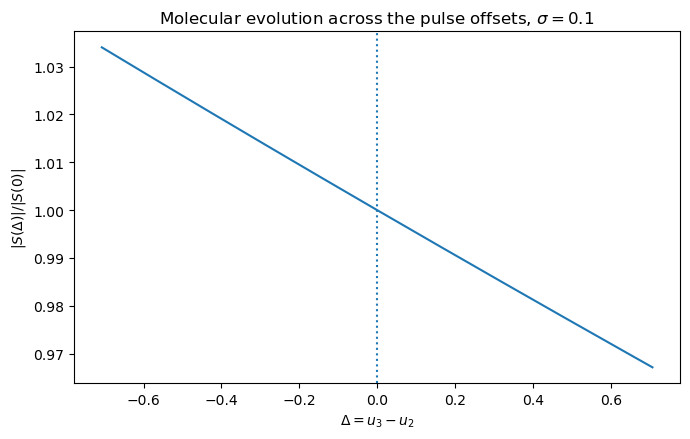

In [12]:
plt.figure(
    figsize=(7, 4.5)
)

plt.plot(
    delta_grid,
    np.abs(S_grid) / abs(S0)
)

plt.axvline(
    0.0,
    linestyle=":"
)

plt.xlabel(
    r"$\Delta=u_3-u_2$"
)

plt.ylabel(
    r"$|S(\Delta)|/|S(0)|$"
)

plt.title(
    r"Molecular evolution across the pulse offsets, $\sigma=0.1$"
)

plt.tight_layout()
plt.show()

### 4.2 Finite-pulse response for $\sigma=0.1$

The exact separated-pulse response at the selected resonant point is

$$
P_{\mathrm{sep}}^{(3)}(\sigma)
=
\int d\Delta\,
h_\sigma(\Delta)
S(\Delta),
$$

with

$$
h_\sigma(\Delta)
=
\frac{1}{\sqrt{4\pi}\sigma}
\exp\left(
-\frac{\Delta^2}{4\sigma^2}
\right).
$$

The scalar short-pulse approximation is

$$
P_{\mathrm{short}}^{(3)}
=
S(0).
$$

We therefore quantify the short-pulse error as

$$
\epsilon_{\mathrm{short}}
=
\frac{
\left|
P_{\mathrm{sep}}^{(3)}
-
P_{\mathrm{short}}^{(3)}
\right|
}{
\left|
P_{\mathrm{sep}}^{(3)}
\right|
}.
$$

In [13]:
h_delta = (
    np.exp(
        -delta_grid**2
        / (4.0 * sigma**2)
    )
    /
    (
        np.sqrt(4.0 * np.pi)
        * sigma
    )
)

d_delta = (
    delta_grid[1]
    - delta_grid[0]
)

w_delta = np.ones_like(
    delta_grid
)

w_delta[[0, -1]] = 0.5
w_delta *= d_delta

h_norm = np.sum(
    w_delta
    * h_delta
)

P_sep = np.sum(
    w_delta
    * h_delta
    * S_grid
)

P_short = S0

err_short = (
    abs(
        P_sep
        - P_short
    )
    /
    abs(P_sep)
)

print(
    "Integral of h_delta =",
    h_norm
)

print()
print(
    "P_sep   =",
    P_sep
)

print(
    "P_short =",
    P_short
)

print()
print(
    "|P_sep|   =",
    abs(P_sep)
)

print(
    "|P_short| =",
    abs(P_short)
)

print()
print(
    "Short-pulse relative error =",
    err_short
)

print(
    "Short-pulse error (%) =",
    100.0 * err_short
)

Integral of h_delta = 0.9999994259227047

P_sep   = (-99.18843299858335-1538.230446981275j)
P_short = (-99.14239635381105-1538.1986191049132j)

|P_sep|   = 1541.4250722175657
|P_short| = 1541.3903485396027

Short-pulse relative error = 3.630907995798991e-05
Short-pulse error (%) = 0.003630907995798991


In [14]:
amplitude_ratio = (
    abs(P_sep)
    / abs(P_short)
)

phase_difference = (
    np.angle(
        P_sep
        / P_short
    )
)

print(
    "|P_sep| / |P_short| =",
    amplitude_ratio
)

print(
    "phase difference (rad) =",
    phase_difference
)

print(
    "phase difference (deg) =",
    np.degrees(
        phase_difference
    )
)

|P_sep| / |P_short| = 1.0000225275044676
phase difference (rad) = -2.847634037627079e-05
phase difference (deg) = -0.0016315741195382948


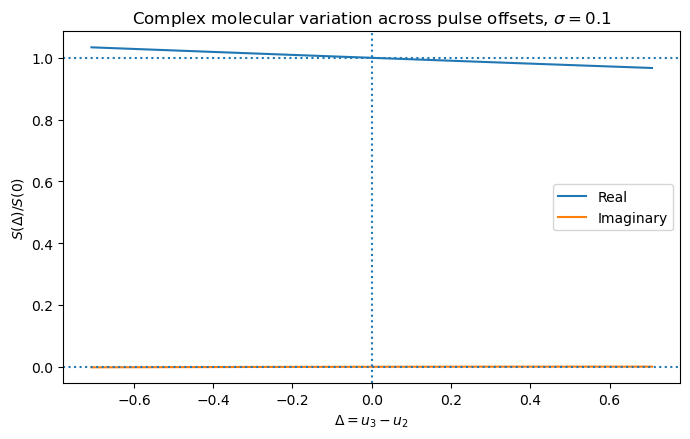

In [15]:
S_ratio = (
    S_grid
    / S0
)

plt.figure(
    figsize=(7, 4.5)
)

plt.plot(
    delta_grid,
    np.real(S_ratio),
    label="Real"
)

plt.plot(
    delta_grid,
    np.imag(S_ratio),
    label="Imaginary"
)

plt.axhline(
    1.0,
    linestyle=":"
)

plt.axhline(
    0.0,
    linestyle=":"
)

plt.axvline(
    0.0,
    linestyle=":"
)

plt.xlabel(
    r"$\Delta=u_3-u_2$"
)

plt.ylabel(
    r"$S(\Delta)/S(0)$"
)

plt.title(
    r"Complex molecular variation across pulse offsets, $\sigma=0.1$"
)

plt.legend()

plt.tight_layout()
plt.show()

### 4.3 Small-width expansion

The very small short-pulse error can be understood by expanding the
molecular response around zero pulse-time difference,

$$
S(\Delta)
=
S(0)
+
\Delta S'(0)
+
\frac{\Delta^2}{2}S''(0)
+
\mathcal{O}(\Delta^3).
$$

Because the Gaussian difference distribution is even,

$$
h_\sigma(-\Delta)=h_\sigma(\Delta),
$$

all odd moments vanish,

$$
\langle\Delta\rangle=0.
$$

Furthermore,

$$
\langle\Delta^2\rangle
=
2\sigma^2.
$$

Therefore,

$$
P_{\mathrm{sep}}^{(3)}
=
S(0)
+
\sigma^2 S''(0)
+
\mathcal{O}(\sigma^4).
$$

Thus the leading error of the scalar short-pulse approximation is
quadratic in the pulse width for symmetric Gaussian pulses.

In [16]:
wait0 = (
    expm(
        L_super * T_wait
    )
    @ pre_wait
)

S1 = (
    mu_bra
    @ np.linalg.solve(
        A3,
        V_up
        @ (
            L_super
            @ wait0
        )
    )
)

S2 = (
    mu_bra
    @ np.linalg.solve(
        A3,
        V_up
        @ (
            L_super
            @ L_super
            @ wait0
        )
    )
)

print("S(0)   =", S0)
print("S'(0)  =", S1)
print("S''(0) =", S2)

S(0)   = (-99.14239635381105-1538.1986191049132j)
S'(0)  = (7.066563336721225+72.48808814950655j)
S''(0) = (-4.610728342263612-3.269887949370256j)


In [17]:
P_quadratic = (
    S0
    + sigma**2 * S2
)

print()
print("P_sep exact      =", P_sep)
print("P quadratic      =", P_quadratic)
print("P_short          =", P_short)

print()

print(
    "Exact correction =",
    P_sep - P_short
)

print(
    "sigma^2 S''(0)   =",
    sigma**2 * S2
)

print()

print(
    "quadratic prediction relative error =",
    abs(
        P_sep
        - P_quadratic
    )
    / abs(P_sep)
)


P_sep exact      = (-99.18843299858335-1538.230446981275j)
P quadratic      = (-99.1885036372337-1538.2313179844068j)
P_short          = (-99.14239635381105-1538.1986191049132j)

Exact correction = (-0.046036644772300406-0.03182787636183093j)
sigma^2 S''(0)   = (-0.046107283422636126-0.032698879493702565j)

quadratic prediction relative error = 5.669187962983793e-07


## 5. Breakdown of the short-pulse approximation

We now vary the Gaussian pulse width while keeping the carrier
frequencies resonant and the waiting time fixed at $T=5$.

For each width, the separated finite-pulse response is evaluated as

$$
P_{\mathrm{sep}}^{(3)}(\sigma)
=
\int d\Delta\,
h_\sigma(\Delta)S(\Delta),
$$

and compared with

$$
P_{\mathrm{short}}^{(3)}
=
S(0).
$$

For sufficiently small $\sigma$, the expansion derived above predicts

$$
\epsilon_{\mathrm{short}}
\propto
\sigma^2.
$$

The purpose of the sweep is to verify this scaling and determine the
range over which the scalar short-pulse approximation remains accurate
for the present dimer.

In [18]:
sigma_values = np.array([
    0.02,
    0.05,
    0.10,
    0.15,
    0.20,
    0.30,
    0.40,
])

P_sep_values = []
error_values = []
amplitude_ratios = []
phase_differences = []

for sigma_i in sigma_values:

    sigma_delta_i = (
        np.sqrt(2.0)
        * sigma_i
    )

    # ±6 standard deviations of the difference distribution
    delta_max_i = (
        6.0
        * sigma_delta_i
    )

    delta_i = np.linspace(
        -delta_max_i,
        delta_max_i,
        401
    )

    d_delta_i = (
        delta_i[1]
        - delta_i[0]
    )

    h_i = (
        np.exp(
            -delta_i**2
            / (4.0 * sigma_i**2)
        )
        /
        (
            np.sqrt(4.0 * np.pi)
            * sigma_i
        )
    )

    w_i = np.ones_like(delta_i)
    w_i[[0, -1]] = 0.5
    w_i *= d_delta_i

    S_i = np.array([
        S_delta(delta)
        for delta in delta_i
    ])

    h_norm_i = np.sum(
        w_i * h_i
    )

    P_sep_i = (
        np.sum(
            w_i
            * h_i
            * S_i
        )
        / h_norm_i
    )

    err_i = (
        abs(
            P_sep_i
            - P_short
        )
        /
        abs(P_sep_i)
    )

    amplitude_ratio_i = (
        abs(P_sep_i)
        / abs(P_short)
    )

    phase_i = np.angle(
        P_sep_i
        / P_short
    )

    P_sep_values.append(
        P_sep_i
    )

    error_values.append(
        err_i
    )

    amplitude_ratios.append(
        amplitude_ratio_i
    )

    phase_differences.append(
        phase_i
    )


P_sep_values = np.array(
    P_sep_values
)

error_values = np.array(
    error_values
)

amplitude_ratios = np.array(
    amplitude_ratios
)

phase_differences = np.array(
    phase_differences
)

In [19]:
print(
    f"{'sigma':>8s}"
    f"{'error':>16s}"
    f"{'error (%)':>16s}"
    f"{'|Psep|/|Pshort|':>20s}"
    f"{'phase (deg)':>16s}"
)

for sigma_i, err_i, amp_i, phase_i in zip(
    sigma_values,
    error_values,
    amplitude_ratios,
    phase_differences
):

    print(
        f"{sigma_i:8.3f}"
        f"{err_i:16.6e}"
        f"{100.0*err_i:16.6f}"
        f"{amp_i:20.9f}"
        f"{np.degrees(phase_i):16.6f}"
    )

   sigma           error       error (%)     |Psep|/|Pshort|     phase (deg)
   0.020    1.466858e-06        0.000147         1.000000924       -0.000065
   0.050    9.167702e-06        0.000917         1.000005774       -0.000408
   0.100    3.666854e-05        0.003667         1.000023102       -0.001632
   0.150    8.249573e-05        0.008250         1.000052002       -0.003670
   0.200    1.466380e-04        0.014664         1.000092503       -0.006520
   0.300    3.298001e-04        0.032980         1.000208491       -0.014645
   0.400    5.859760e-04        0.058598         1.000371537       -0.025974


In [20]:
P_quadratic_values = (
    S0
    + sigma_values**2 * S2
)

quadratic_error_values = (
    np.abs(
        P_quadratic_values
        - P_short
    )
    /
    np.abs(P_quadratic_values)
)

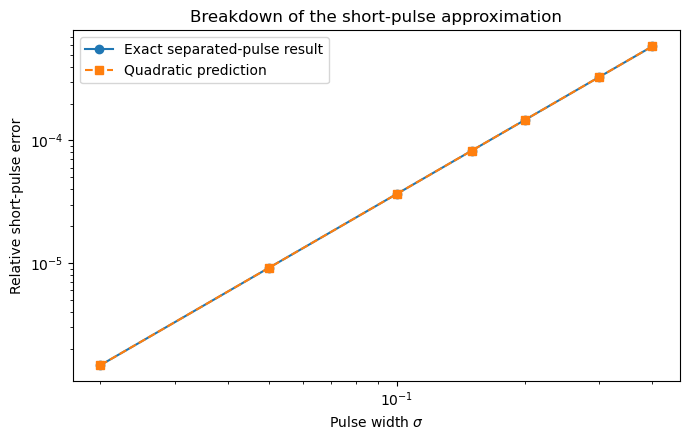

In [23]:
plt.figure(
    figsize=(7, 4.5)
)

plt.loglog(
    sigma_values,
    error_values,
    "o-",
    label="Exact separated-pulse result"
)

plt.loglog(
    sigma_values,
    quadratic_error_values,
    "s--",
    label=r"Quadratic prediction"
)

plt.xlabel(
    r"Pulse width $\sigma$"
)

plt.ylabel(
    r"Relative short-pulse error"
)

plt.title(
    "Breakdown of the short-pulse approximation"
)

plt.legend()

plt.tight_layout()

figures_dir = repo_root / "figures"
figures_dir.mkdir(exist_ok=True)

plt.savefig(
    figures_dir / "short_pulse_quadratic_scaling.pdf",
    bbox_inches="tight"
)

plt.show()

In [24]:
small_mask = (
    sigma_values <= 0.15
)

slope, intercept = np.polyfit(
    np.log(
        sigma_values[small_mask]
    ),
    np.log(
        error_values[small_mask]
    ),
    1
)

print(
    "Small-width scaling exponent =",
    slope
)

Small-width scaling exponent = 1.9999169864332629


## 6. Short-pulse accuracy at different spectral features

The upper-exciton diagonal peak provides a particularly clean first
benchmark, but it does not establish that the approximation is equally
accurate throughout the two-dimensional spectrum.

We therefore evaluate the same finite-pulse correction at the four
characteristic excitonic frequency combinations,

$$
(\Omega_-,\Omega_-),
\qquad
(\Omega_+,\Omega_+),
$$

$$
(\Omega_-,\Omega_+),
\qquad
(\Omega_+,\Omega_-).
$$

For each point, the carrier frequencies are chosen resonantly so that
the scalar pulse factors are unity.  This isolates the molecular
finite-width correction from spectral filtering.

In [25]:
def build_NR_point(omega3, omega1):

    A1_point = (
        (eta - 1j * omega1) * I16
        - L_super
    )

    A3_point = (
        (eta - 1j * omega3) * I16
        - L_super
    )

    pre_wait_point = (
        V_down
        @ np.linalg.solve(
            A1_point,
            V_up @ rho_ss_vec
        )
    )

    def S_point(delta):

        x = (
            expm(
                L_super
                * (T_wait + delta)
            )
            @ pre_wait_point
        )

        x = V_up @ x

        x = np.linalg.solve(
            A3_point,
            x
        )

        return mu_bra @ x

    return S_point

In [26]:
def separated_pulse_point(
    omega3,
    omega1,
    sigma,
    N_delta=401,
    n_sigma=6.0,
):

    S_point = build_NR_point(
        omega3,
        omega1
    )

    sigma_delta = (
        np.sqrt(2.0)
        * sigma
    )

    delta_max = (
        n_sigma
        * sigma_delta
    )

    delta = np.linspace(
        -delta_max,
        delta_max,
        N_delta
    )

    d_delta = (
        delta[1]
        - delta[0]
    )

    h = (
        np.exp(
            -delta**2
            / (4.0 * sigma**2)
        )
        /
        (
            np.sqrt(4.0 * np.pi)
            * sigma
        )
    )

    w = np.ones_like(delta)
    w[[0, -1]] = 0.5
    w *= d_delta

    S_values = np.array([
        S_point(x)
        for x in delta
    ])

    norm_h = np.sum(
        w * h
    )

    P_sep = (
        np.sum(
            w
            * h
            * S_values
        )
        /
        norm_h
    )

    P_short = S_point(0.0)

    error = (
        abs(
            P_sep
            - P_short
        )
        /
        abs(P_sep)
    )

    return (
        P_sep,
        P_short,
        error,
    )

In [27]:
sigma_test = 0.2

peak_points = {
    "lower-lower": (
        omega_minus,
        omega_minus,
    ),

    "upper-upper": (
        omega_plus,
        omega_plus,
    ),

    "lower-upper": (
        omega_plus,
        omega_minus,
    ),

    "upper-lower": (
        omega_minus,
        omega_plus,
    ),
}

peak_results = {}

for name, (
    omega3_i,
    omega1_i
) in peak_points.items():

    P_sep_i, P_short_i, err_i = (
        separated_pulse_point(
            omega3_i,
            omega1_i,
            sigma_test
        )
    )

    peak_results[name] = (
        P_sep_i,
        P_short_i,
        err_i
    )

    print(name)

    print(
        "  omega1 =",
        omega1_i
    )

    print(
        "  omega3 =",
        omega3_i
    )

    print(
        "  |P_short| =",
        abs(P_short_i)
    )

    print(
        "  error =",
        err_i
    )

    print(
        "  error (%) =",
        100.0 * err_i
    )

    print()

lower-lower
  omega1 = 0.9585786437626906
  omega3 = 0.9585786437626906
  |P_short| = 85.66527378678403
  error = 0.002151539649371328
  error (%) = 0.2151539649371328

upper-upper
  omega1 = 1.2414213562373095
  omega3 = 1.2414213562373095
  |P_short| = 1541.3903485396027
  error = 0.00014663796958175795
  error (%) = 0.014663796958175795

lower-upper
  omega1 = 0.9585786437626906
  omega3 = 1.2414213562373095
  |P_short| = 291.32332454992724
  error = 0.00027201265987845995
  error (%) = 0.027201265987845995

upper-lower
  omega1 = 1.2414213562373095
  omega3 = 0.9585786437626906
  |P_short| = 403.0239672158361
  error = 8.258169045995066e-05
  error (%) = 0.008258169045995066



## 7. Conservative short-pulse criterion

Among the four characteristic excitonic features, the lower-lower
diagonal response shows the largest relative finite-width correction.

We therefore use

$$
(\omega_1,\omega_3)
=
(\Omega_-,\Omega_-)
$$

as a conservative test of the short-pulse approximation.

For symmetric Gaussian pulses, the small-width expansion predicts

$$
\epsilon_{\mathrm{short}}
\propto
\sigma^2,
$$

but the exact separated-pulse convolution allows us to determine when
higher-order corrections become important.

In [28]:
sigma_worst = np.array([
    0.02,
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
])

error_worst = []

for sigma_i in sigma_worst:

    P_sep_i, P_short_i, err_i = (
        separated_pulse_point(
            omega_minus,
            omega_minus,
            sigma_i
        )
    )

    error_worst.append(
        err_i
    )

error_worst = np.array(
    error_worst
)

print(
    f"{'sigma':>8s}"
    f"{'error':>16s}"
    f"{'error (%)':>16s}"
)

for sigma_i, err_i in zip(
    sigma_worst,
    error_worst
):

    print(
        f"{sigma_i:8.3f}"
        f"{err_i:16.6e}"
        f"{100.0*err_i:16.6f}"
    )

   sigma           error       error (%)
   0.020    2.151862e-05        0.002152
   0.050    1.344903e-04        0.013449
   0.100    5.379462e-04        0.053795
   0.150    1.210322e-03        0.121032
   0.200    2.151540e-03        0.215154
   0.250    3.361490e-03        0.336149
   0.300    4.840027e-03        0.484003
   0.350    6.586969e-03        0.658697
   0.400    8.602093e-03        0.860209
   0.450    1.088513e-02        1.088513
   0.500    1.343577e-02        1.343577


In [29]:
S_LL = build_NR_point(
    omega_minus,
    omega_minus
)

S0_LL = S_LL(0.0)

A1_LL = (
    (eta - 1j * omega_minus) * I16
    - L_super
)

A3_LL = (
    (eta - 1j * omega_minus) * I16
    - L_super
)

pre_wait_LL = (
    V_down
    @ np.linalg.solve(
        A1_LL,
        V_up @ rho_ss_vec
    )
)

wait_LL = (
    expm(
        L_super * T_wait
    )
    @ pre_wait_LL
)

S2_LL = (
    mu_bra
    @ np.linalg.solve(
        A3_LL,
        V_up
        @ (
            L_super
            @ L_super
            @ wait_LL
        )
    )
)

print("S_LL(0)   =", S0_LL)
print("S_LL''(0) =", S2_LL)

S_LL(0)   = (78.82964985266042-33.532453490187976j)
S_LL''(0) = (-4.164898602785069-1.97279743784433j)


In [31]:
P_quad_LL = (
    S0_LL
    + sigma_worst**2 * S2_LL
)

error_quad_LL = (
    np.abs(
        P_quad_LL
        - S0_LL
    )
    /
    np.abs(P_quad_LL)
)

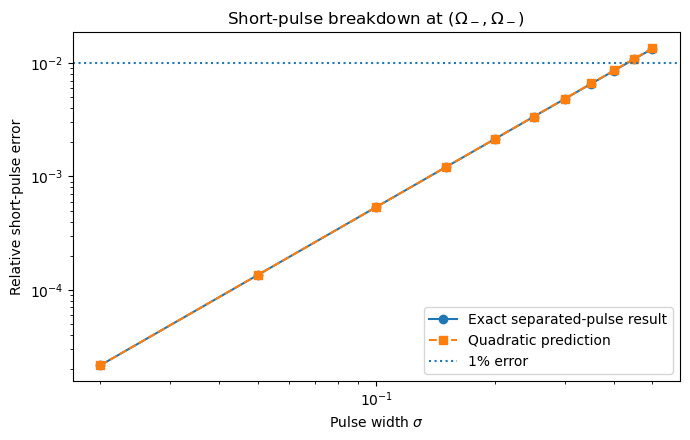

In [33]:
plt.figure(
    figsize=(7, 4.5)
)

plt.loglog(
    sigma_worst,
    error_worst,
    "o-",
    label="Exact separated-pulse result"
)

plt.loglog(
    sigma_worst,
    error_quad_LL,
    "s--",
    label=r"Quadratic prediction"
)

plt.axhline(
    0.01,
    linestyle=":",
    label="1% error"
)

plt.xlabel(
    r"Pulse width $\sigma$"
)

plt.ylabel(
    r"Relative short-pulse error"
)

plt.title(
    r"Short-pulse breakdown at $(\Omega_-,\Omega_-)$"
)

plt.legend()

plt.tight_layout()
plt.savefig(
    figures_dir / "short_pulse_breakdown_lower_lower.pdf",
    bbox_inches="tight"
)

plt.show()

### 7.1 Conservative short-pulse criterion

The lower-lower excitonic feature is the most sensitive of the four
characteristic spectral positions tested.

For this feature, the exact separated-pulse calculation remains below
$1\%$ relative error up to approximately

$$
\boxed{
\sigma \simeq 0.43
}.
$$

The numerical results remain very close to the quadratic small-width
prediction over the entire tested interval,

$$
\epsilon_{\mathrm{short}}
\propto
\sigma^2.
$$

Thus, for the present dimer and waiting time $T=5$, pulse widths
$\sigma \lesssim 0.4$ provide a conservative regime in which the scalar
short-pulse approximation remains accurate to better than approximately
$1\%$ at the characteristic excitonic features.

## 8. Fixed-carrier short-pulse spectrum

The previous calculations retuned the carrier frequency at each spectral
point in order to isolate the dynamical error of the short-pulse
approximation.

We now consider a physical experiment in which all three pulses have a
single fixed carrier frequency.

For equal Gaussian pulses we choose

$$
\omega_L
=
\frac{\Omega_-+\Omega_+}{2},
$$

so that the carrier lies midway between the two one-exciton
transitions.

For the nonrephasing branch $(+,-,+)$,

$$
P_{NR,\mathrm{short}}^{(3)}
(\omega_3,T,\omega_1)
=
E_3^{(+)}(\omega_3)
E_2^{(-)}(-\omega_1)
E_1^{(+)}(\omega_1)
M_{NR}^{(3)}
(\omega_3,T,\omega_1).
$$

For area-normalized Gaussian pulses of equal width $\sigma$,

$$
E_1^{(+)}(\omega_1)
=
\exp\left[
-\frac{\sigma^2}{2}
(\omega_1-\omega_L)^2
\right],
$$

$$
E_2^{(-)}(-\omega_1)
=
\exp\left[
-\frac{\sigma^2}{2}
(\omega_1-\omega_L)^2
\right],
$$

and

$$
E_3^{(+)}(\omega_3)
=
\exp\left[
-\frac{\sigma^2}{2}
(\omega_3-\omega_L)^2
\right].
$$

Therefore,

$$
\boxed{
P_{NR,\mathrm{short}}^{(3)}
=
e^{-\sigma^2(\omega_1-\omega_L)^2}
e^{-\frac{\sigma^2}{2}(\omega_3-\omega_L)^2}
M_{NR}^{(3)}.
}
$$

In [34]:
omega_L = 0.5 * (
    omega_minus
    + omega_plus
)

sigma_short = 0.2

print(
    "omega_L =",
    omega_L
)

print(
    "sigma =",
    sigma_short
)

omega_L = 1.1
sigma = 0.2


In [35]:
prop_T = expm(
    L_super * T_wait
)

M_NR = np.zeros(
    (
        len(omega3_grid),
        len(omega1_grid),
    ),
    dtype=complex,
)

for i1, omega1 in enumerate(
    omega1_grid
):

    A1 = (
        (eta - 1j * omega1) * I16
        - L_super
    )

    x1 = np.linalg.solve(
        A1,
        V_up @ rho_ss_vec
    )

    x2 = (
        V_down
        @ x1
    )

    xT = (
        prop_T
        @ x2
    )

    x3 = (
        V_up
        @ xT
    )

    for i3, omega3 in enumerate(
        omega3_grid
    ):

        A3 = (
            (eta - 1j * omega3) * I16
            - L_super
        )

        y = np.linalg.solve(
            A3,
            x3
        )

        M_NR[i3, i1] = (
            mu_bra
            @ y
        )

print(
    "M_NR shape =",
    M_NR.shape
)

print(
    "max |M_NR| =",
    np.max(
        np.abs(M_NR)
    )
)

M_NR shape = (201, 201)
max |M_NR| = 1543.7534471483443


In [36]:
E1_filter = np.exp(
    -0.5
    * sigma_short**2
    * (
        omega1_grid
        - omega_L
    )**2
)

E2_filter = np.exp(
    -0.5
    * sigma_short**2
    * (
        omega1_grid
        - omega_L
    )**2
)

E3_filter = np.exp(
    -0.5
    * sigma_short**2
    * (
        omega3_grid
        - omega_L
    )**2
)

first_axis_filter = (
    E1_filter
    * E2_filter
)

pulse_filter_NR = (
    E3_filter[:, None]
    * first_axis_filter[None, :]
)

P_NR_short = (
    pulse_filter_NR
    * M_NR
)

print(
    "filter min =",
    np.min(
        pulse_filter_NR
    )
)

print(
    "filter max =",
    np.max(
        pulse_filter_NR
    )
)

print(
    "max |M_NR| =",
    np.max(
        np.abs(M_NR)
    )
)

print(
    "max |P_NR_short| =",
    np.max(
        np.abs(P_NR_short)
    )
)

filter min = 0.9851119396030628
filter max = 1.0
max |M_NR| = 1543.7534471483443
max |P_NR_short| = 1541.973106553469


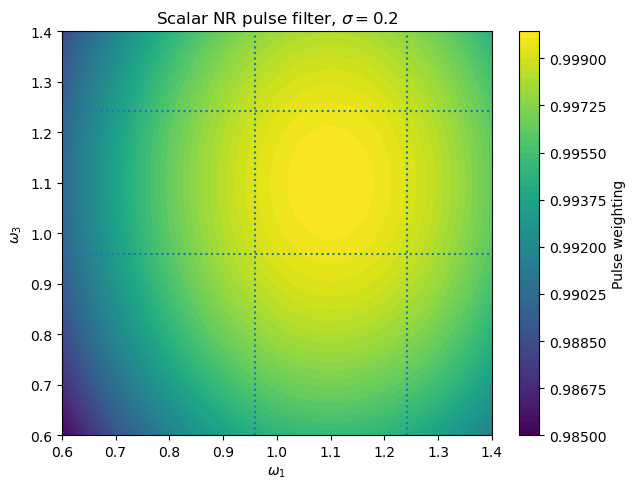

In [37]:
plt.figure(
    figsize=(6.5, 5)
)

plt.contourf(
    omega1_grid,
    omega3_grid,
    pulse_filter_NR,
    levels=60
)

plt.axvline(
    omega_minus,
    linestyle=":"
)

plt.axvline(
    omega_plus,
    linestyle=":"
)

plt.axhline(
    omega_minus,
    linestyle=":"
)

plt.axhline(
    omega_plus,
    linestyle=":"
)

plt.xlabel(
    r"$\omega_1$"
)

plt.ylabel(
    r"$\omega_3$"
)

plt.title(
    rf"Scalar NR pulse filter, $\sigma={sigma_short}$"
)

plt.colorbar(
    label="Pulse weighting"
)

plt.tight_layout()
plt.show()

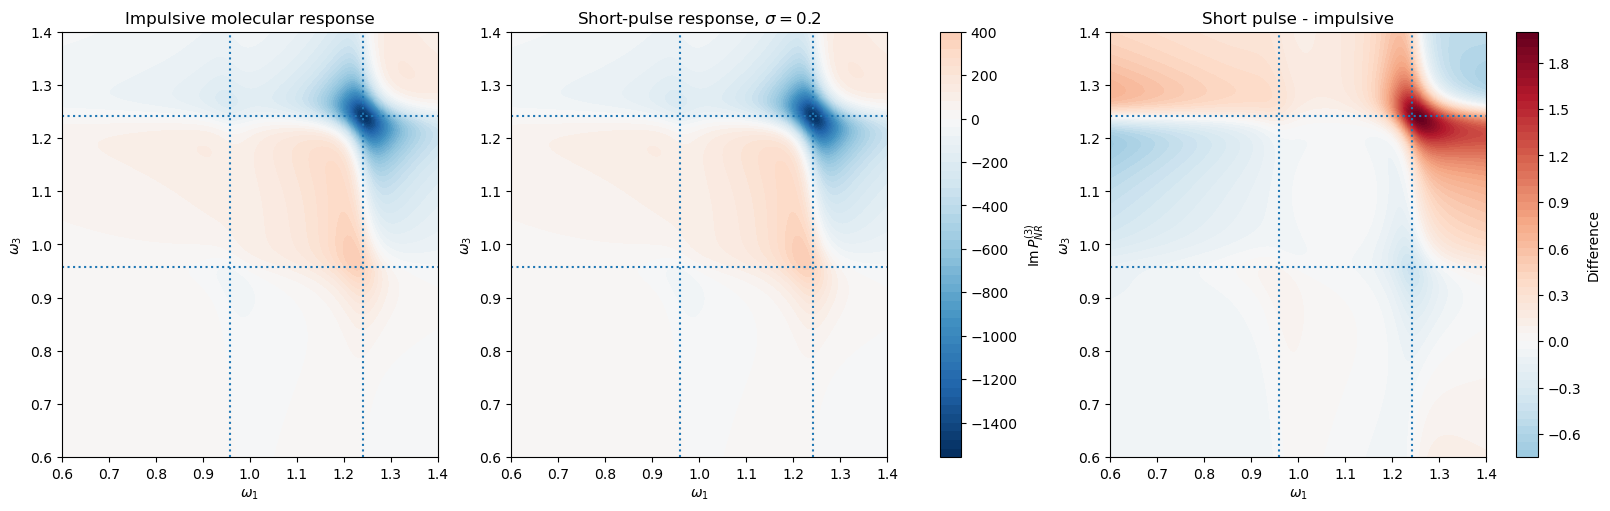

In [38]:
vmax = max(
    np.max(
        np.abs(
            np.imag(M_NR)
        )
    ),
    np.max(
        np.abs(
            np.imag(P_NR_short)
        )
    ),
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5),
    constrained_layout=True
)

im0 = axes[0].contourf(
    omega1_grid,
    omega3_grid,
    np.imag(M_NR),
    levels=60,
    vmin=-vmax,
    vmax=vmax,
    cmap="RdBu_r"
)

axes[0].set_title(
    "Impulsive molecular response"
)

im1 = axes[1].contourf(
    omega1_grid,
    omega3_grid,
    np.imag(P_NR_short),
    levels=60,
    vmin=-vmax,
    vmax=vmax,
    cmap="RdBu_r"
)

axes[1].set_title(
    rf"Short-pulse response, $\sigma={sigma_short}$"
)

difference_short = (
    np.imag(P_NR_short)
    - np.imag(M_NR)
)

diff_max = np.max(
    np.abs(
        difference_short
    )
)

im2 = axes[2].contourf(
    omega1_grid,
    omega3_grid,
    difference_short,
    levels=60,
    vmin=-diff_max,
    vmax=diff_max,
    cmap="RdBu_r"
)

axes[2].set_title(
    "Short pulse - impulsive"
)

for ax in axes:

    ax.axvline(
        omega_minus,
        linestyle=":"
    )

    ax.axvline(
        omega_plus,
        linestyle=":"
    )

    ax.axhline(
        omega_minus,
        linestyle=":"
    )

    ax.axhline(
        omega_plus,
        linestyle=":"
    )

    ax.set_xlabel(
        r"$\omega_1$"
    )

    ax.set_ylabel(
        r"$\omega_3$"
    )

fig.colorbar(
    im0,
    ax=axes[:2],
    label=r"$\mathrm{Im}\,P_{NR}^{(3)}$"
)

fig.colorbar(
    im2,
    ax=axes[2],
    label="Difference"
)

plt.show()

In [39]:
spectral_filter_change = (
    norm(
        P_NR_short
        - M_NR
    )
    /
    norm(M_NR)
)

print(
    "Relative change caused by scalar pulse filtering =",
    spectral_filter_change
)

print(
    "Relative change (%) =",
    100.0
    * spectral_filter_change
)

Relative change caused by scalar pulse filtering = 0.001795155138663792
Relative change (%) = 0.1795155138663792


### 8.1 Spectral filtering near the edge of the short-pulse regime

For $\sigma=0.2$, the pulse is sufficiently broadband that the scalar
spectral filter varies by less than approximately $1.5\%$ over the
entire frequency window.

We therefore repeat the calculation at

$$
\sigma=0.4,
$$

which remains within approximately $1\%$ short-pulse error at the most
sensitive characteristic excitonic feature.

This provides a useful example in which spectral filtering becomes more
visible while the scalar short-pulse approximation remains
quantitatively accurate.

In [40]:
sigma_short_2 = 0.4

E1_filter_2 = np.exp(
    -0.5
    * sigma_short_2**2
    * (omega1_grid - omega_L)**2
)

E2_filter_2 = np.exp(
    -0.5
    * sigma_short_2**2
    * (omega1_grid - omega_L)**2
)

E3_filter_2 = np.exp(
    -0.5
    * sigma_short_2**2
    * (omega3_grid - omega_L)**2
)

pulse_filter_NR_2 = (
    E3_filter_2[:, None]
    * (
        E1_filter_2
        * E2_filter_2
    )[None, :]
)

P_NR_short_2 = (
    pulse_filter_NR_2
    * M_NR
)

filtering_change_2 = (
    norm(
        P_NR_short_2
        - M_NR
    )
    /
    norm(M_NR)
)

print(
    "sigma =",
    sigma_short_2
)

print(
    "filter min =",
    np.min(pulse_filter_NR_2)
)

print(
    "filter max =",
    np.max(pulse_filter_NR_2)
)

print(
    "max |M_NR| =",
    np.max(np.abs(M_NR))
)

print(
    "max |P_NR_short| =",
    np.max(np.abs(P_NR_short_2))
)

print(
    "relative scalar-filtering change =",
    filtering_change_2
)

print(
    "relative scalar-filtering change (%) =",
    100.0 * filtering_change_2
)

sigma = 0.4
filter min = 0.9417645335842485
filter max = 1.0
max |M_NR| = 1543.7534471483443
max |P_NR_short| = 1536.6443944149023
relative scalar-filtering change = 0.007143169486378174
relative scalar-filtering change (%) = 0.7143169486378175


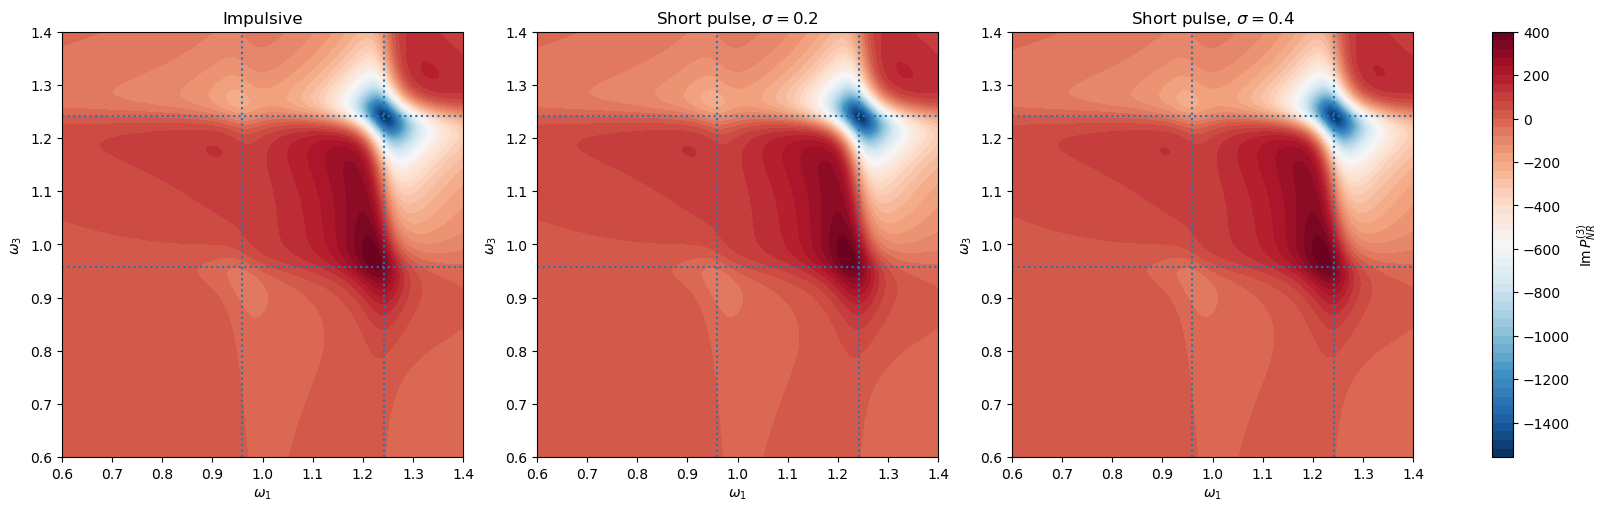

In [41]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5),
    constrained_layout=True
)

im0 = axes[0].contourf(
    omega1_grid,
    omega3_grid,
    np.imag(M_NR),
    levels=60,
    cmap="RdBu_r"
)

axes[0].set_title(
    "Impulsive"
)

im1 = axes[1].contourf(
    omega1_grid,
    omega3_grid,
    np.imag(P_NR_short),
    levels=60,
    cmap="RdBu_r"
)

axes[1].set_title(
    r"Short pulse, $\sigma=0.2$"
)

im2 = axes[2].contourf(
    omega1_grid,
    omega3_grid,
    np.imag(P_NR_short_2),
    levels=60,
    cmap="RdBu_r"
)

axes[2].set_title(
    r"Short pulse, $\sigma=0.4$"
)

for ax in axes:

    ax.axvline(
        omega_minus,
        linestyle=":"
    )

    ax.axvline(
        omega_plus,
        linestyle=":"
    )

    ax.axhline(
        omega_minus,
        linestyle=":"
    )

    ax.axhline(
        omega_plus,
        linestyle=":"
    )

    ax.set_xlabel(
        r"$\omega_1$"
    )

    ax.set_ylabel(
        r"$\omega_3$"
    )

fig.colorbar(
    im0,
    ax=axes,
    label=r"$\mathrm{Im}\,P_{NR}^{(3)}$"
)

plt.show()

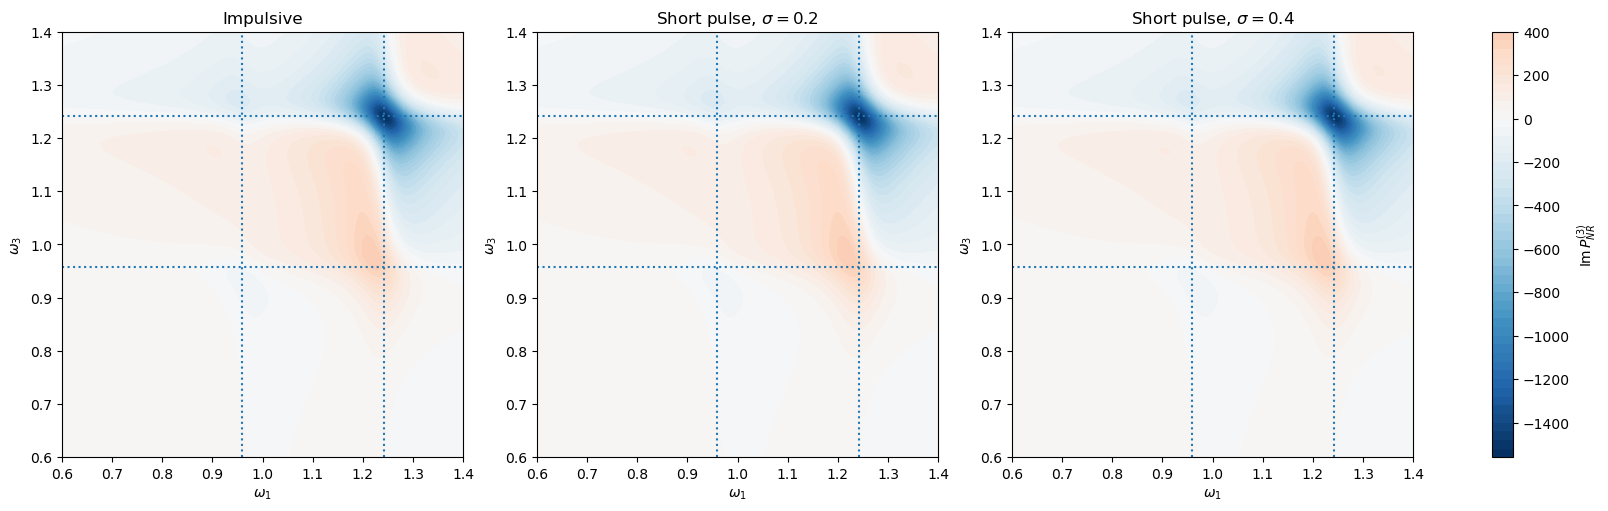

In [46]:
vmax_compare = max(
    np.max(np.abs(np.imag(M_NR))),
    np.max(np.abs(np.imag(P_NR_short))),
    np.max(np.abs(np.imag(P_NR_short_2))),
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5),
    constrained_layout=True
)

maps = [
    np.imag(M_NR),
    np.imag(P_NR_short),
    np.imag(P_NR_short_2),
]

titles = [
    "Impulsive",
    r"Short pulse, $\sigma=0.2$",
    r"Short pulse, $\sigma=0.4$",
]

for ax, data, title in zip(
    axes,
    maps,
    titles,
):

    im = ax.contourf(
        omega1_grid,
        omega3_grid,
        data,
        levels=60,
        vmin=-vmax_compare,
        vmax=vmax_compare,
        cmap="RdBu_r"
    )

    ax.axvline(
        omega_minus,
        linestyle=":"
    )

    ax.axvline(
        omega_plus,
        linestyle=":"
    )

    ax.axhline(
        omega_minus,
        linestyle=":"
    )

    ax.axhline(
        omega_plus,
        linestyle=":"
    )

    ax.set_xlabel(
        r"$\omega_1$"
    )

    ax.set_ylabel(
        r"$\omega_3$"
    )

    ax.set_title(
        title
    )

fig.colorbar(
    im,
    ax=axes,
    label=r"$\mathrm{Im}\,P_{NR}^{(3)}$"
)

fig.savefig(
    figures_dir / "short_pulse_spectral_filtering.pdf",
    bbox_inches="tight"
)

plt.show()

## 9. Time-bandwidth tradeoff

Increasing the pulse width has two distinct consequences.

First, the Gaussian spectrum becomes narrower, so scalar spectral
filtering increasingly reshapes the impulsive molecular spectrum.

Second, molecular evolution during the pulse offsets becomes more
important, reducing the accuracy of the scalar short-pulse
approximation.

We therefore compare

$$
\epsilon_{\mathrm{dyn}}(\sigma)
=
\frac{
|P_{\mathrm{sep}}^{(3)}-P_{\mathrm{short}}^{(3)}|
}{
|P_{\mathrm{sep}}^{(3)}|
},
$$

evaluated at the most sensitive characteristic excitonic feature, with

$$
\epsilon_{\mathrm{filter}}(\sigma)
=
\frac{
\|P_{\mathrm{short}}^{(3)}-M^{(3)}\|_2
}{
\|M^{(3)}\|_2
},
$$

which measures the physical spectral reshaping caused by the scalar
pulse spectra.

The first quantity is an approximation error.  The second is a
physical pulse-filtering effect.  They should therefore not be
interpreted as the same type of error.

In [47]:
filtering_change_values = []

for sigma_i in sigma_worst:

    E1_i = np.exp(
        -0.5
        * sigma_i**2
        * (omega1_grid - omega_L)**2
    )

    E2_i = np.exp(
        -0.5
        * sigma_i**2
        * (omega1_grid - omega_L)**2
    )

    E3_i = np.exp(
        -0.5
        * sigma_i**2
        * (omega3_grid - omega_L)**2
    )

    filter_i = (
        E3_i[:, None]
        * (E1_i * E2_i)[None, :]
    )

    P_short_i = (
        filter_i
        * M_NR
    )

    change_i = (
        norm(
            P_short_i
            - M_NR
        )
        /
        norm(M_NR)
    )

    filtering_change_values.append(
        change_i
    )

filtering_change_values = np.array(
    filtering_change_values
)

In [48]:
print(
    f"{'sigma':>8s}"
    f"{'dyn. error (%)':>18s}"
    f"{'filtering (%)':>18s}"
)

for sigma_i, dyn_i, filt_i in zip(
    sigma_worst,
    error_worst,
    filtering_change_values
):

    print(
        f"{sigma_i:8.3f}"
        f"{100.0*dyn_i:18.6f}"
        f"{100.0*filt_i:18.6f}"
    )

   sigma    dyn. error (%)     filtering (%)
   0.020          0.002152          0.001798
   0.050          0.013449          0.011238
   0.100          0.053795          0.044938
   0.150          0.121032          0.101055
   0.200          0.215154          0.179516
   0.250          0.336149          0.280217
   0.300          0.484003          0.403029
   0.350          0.658697          0.547791
   0.400          0.860209          0.714317
   0.450          1.088513          0.902394
   0.500          1.343577          1.111782


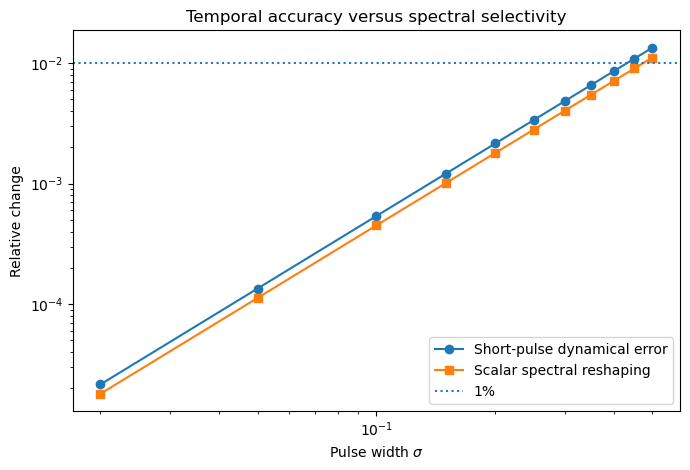

In [49]:
plt.figure(
    figsize=(7, 4.8)
)

plt.loglog(
    sigma_worst,
    error_worst,
    "o-",
    label="Short-pulse dynamical error"
)

plt.loglog(
    sigma_worst,
    filtering_change_values,
    "s-",
    label="Scalar spectral reshaping"
)

plt.axhline(
    0.01,
    linestyle=":",
    label="1%"
)

plt.xlabel(
    r"Pulse width $\sigma$"
)

plt.ylabel(
    "Relative change"
)

plt.title(
    "Temporal accuracy versus spectral selectivity"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    figures_dir / "short_pulse_tradeoff.pdf",
    bbox_inches="tight"
)

plt.show()

## 10. Conclusion

The scalar short-pulse approximation has been tested against an exact
separated-pulse convolution for the thermal dimer.

For symmetric Gaussian pulses, the molecular response can be expanded
in the pulse-time difference,

$$
S(\Delta)
=
S(0)
+
\Delta S'(0)
+
\frac{\Delta^2}{2}S''(0)
+\cdots.
$$

Because the distribution of pulse-time differences is even, all odd
moments vanish.  The leading finite-width correction is therefore

$$
\boxed{
P_{\mathrm{sep}}^{(3)}
=
P_{\mathrm{short}}^{(3)}
+
\sigma^2 S''(0)
+
\mathcal O(\sigma^4)
}.
$$

The numerical small-width scaling exponent is

$$
p \simeq 1.9999,
$$

confirming

$$
\boxed{
\epsilon_{\mathrm{short}}
\propto \sigma^2.
}
$$

Among the four characteristic excitonic spectral positions, the
lower-lower feature is the most sensitive to molecular evolution during
the pulse offsets.  At this feature, the dynamical error reaches
approximately $1\%$ near

$$
\sigma \simeq 0.43.
$$

The fixed-carrier short-pulse spectrum also exhibits scalar spectral
filtering.  For small pulse widths, this effect is itself quadratic in
$\sigma$, since the Gaussian spectral factors satisfy

$$
E(\omega)
=
1
-
\frac{\sigma^2}{2}
(\omega-\omega_L)^2
+
\mathcal O(\sigma^4).
$$

For the present model, both the finite-width dynamical correction and
the scalar spectral reshaping therefore grow approximately as
$\sigma^2$, with the dynamical correction somewhat larger over the
tested range.

At $\sigma=0.4$, the conservative dynamical error is approximately
$0.86\%$, while scalar filtering changes the complete two-dimensional
spectrum by approximately $0.71\%$.  At $\sigma=0.5$, these quantities
increase to approximately $1.34\%$ and $1.11\%$, respectively.

Thus, very short pulses are both accurately represented by scalar
spectral factors and effectively broadband over the molecular
spectrum.  As the temporal width increases, spectral filtering becomes
more pronounced while molecular evolution during the pulse offsets
simultaneously becomes non-negligible.

This motivates the finite-width formulation, in which pulse effects are
represented by Liouvillian-dependent operator filters rather than
scalar spectral weights.

## 11. Independent driven-ODE validation of the short-pulse approximation

The previous sections compared the scalar short-pulse approximation
against the exact separated-pulse convolution.

We now perform an independent validation using directly driven
time-domain equations of motion with finite Gaussian pulses.

For the nonrephasing branch $(+,-,+)$, we propagate the perturbative
hierarchy

$$
\dot{\rho}^{(1)}
=
\mathcal{L}\rho^{(1)}
+
E_1^{(+)}(t)
V_{\uparrow}\rho_{\mathrm{ss}},
$$

$$
\dot{\rho}^{(2)}
=
\mathcal{L}\rho^{(2)}
+
E_2^{(-)}(t)
V_{\downarrow}\rho^{(1)},
$$

and

$$
\dot{\rho}^{(3)}
=
\mathcal{L}\rho^{(3)}
+
E_3^{(+)}(t)
V_{\uparrow}\rho^{(2)}.
$$

This hierarchy isolates exactly one interaction with each pulse and
therefore directly generates the selected third-order nonrephasing
contribution without extracting a small cubic signal from the complete
driven density matrix.

For a pulse-center coherence delay $\tau_1$, the pulse centers are

$$
t_{1c}=0,
\qquad
t_{2c}=\tau_1,
\qquad
t_{3c}=\tau_1+T.
$$

The resulting third-order polarization is

$$
P_{NR}^{(3)}(t_3,T,\tau_1)
=
\langle\!\langle\mu|
\rho^{(3)}(t_{3c}+t_3)
\rangle\!\rangle.
$$

We transform the directly driven response using the same damped causal
Fourier convention as the resolvent calculation and compare it with

$$
\boxed{
P_{NR,\mathrm{short}}^{(3)}
=
E_3^{(+)}(\omega_3)
E_2^{(-)}(-\omega_1)
E_1^{(+)}(\omega_1)
M_{NR}^{(3)}.
}
$$

In [50]:
from scipy.integrate import solve_ivp, simpson

In [51]:
def gaussian_branch(
    t,
    center,
    sigma,
    omega_L,
    s,
):

    u = t - center

    envelope = (
        np.exp(
            -u**2
            / (2.0 * sigma**2)
        )
        /
        (
            np.sqrt(2.0 * np.pi)
            * sigma
        )
    )

    carrier = np.exp(
        -1j
        * s
        * omega_L
        * u
    )

    return (
        envelope
        * carrier
    )

In [62]:
def NR_ODE_detection_at_tau(
    tau1,
    sigma,
    omega_L,
    omega3,
    n_sigma=6.0,
):

    nL = d**2

    t1c = 0.0
    t2c = tau1
    t3c = tau1 + T_wait

    t_start = (
        t1c
        - n_sigma * sigma
    )

    t_end = (
        t3c
        + n_sigma * sigma
    )

    A3_target = (
        (eta - 1j * omega3) * I16
        - L_super
    )

    # State vector contains:
    #
    # rho^(1)
    # rho^(2)
    # rho^(3)
    # accumulated detection-frequency integral

    y0 = np.zeros(
        3 * nL + 1,
        dtype=complex
    )

    def rhs(t, y):

        rho1 = y[
            0:nL
        ]

        rho2 = y[
            nL:2*nL
        ]

        rho3 = y[
            2*nL:3*nL
        ]

        E1 = gaussian_branch(
            t,
            t1c,
            sigma,
            omega_L,
            +1
        )

        E2 = gaussian_branch(
            t,
            t2c,
            sigma,
            omega_L,
            -1
        )

        E3 = gaussian_branch(
            t,
            t3c,
            sigma,
            omega_L,
            +1
        )

        drho1 = (
            L_super @ rho1
            + E1
            * (
                V_up
                @ rho_ss_vec
            )
        )

        drho2 = (
            L_super @ rho2
            + E2
            * (
                V_down
                @ rho1
            )
        )

        drho3 = (
            L_super @ rho3
            + E3
            * (
                V_up
                @ rho2
            )
        )

        # Detection time measured relative to pulse-3 center.
        #
        # We include the full finite pulse, including t < t3c.
        # Causality is already enforced by rho^(3)(t), which is only
        # generated once the third interaction has occurred.

        t3 = (
            t
            - t3c
        )

        dq = (
            np.exp(
                (
                    1j * omega3
                    - eta
                )
                * t3
            )
            * (
                mu_bra
                @ rho3
            )
        )

        return np.concatenate([
            drho1,
            drho2,
            drho3,
            np.array([dq]),
        ])

    sol = solve_ivp(
        rhs,
        (
            t_start,
            t_end,
        ),
        y0,
        method="DOP853",
        rtol=1e-8,
        atol=1e-10,
        max_step=sigma / 4.0,
    )

    rho3_end = sol.y[
        2*nL:3*nL,
        -1
    ]

    q_during = sol.y[
        -1,
        -1
    ]

    # After t_end, pulse 3 is negligible and rho^(3)
    # evolves freely.  The remaining detection-time
    # Fourier integral is evaluated analytically with
    # the same Liouvillian resolvent.

    t3_end = (
        t_end
        - t3c
    )

    tail_phase = np.exp(
        (
            1j * omega3
            - eta
        )
        * t3_end
    )

    q_tail = (
        tail_phase
        * (
            mu_bra
            @ np.linalg.solve(
                A3_target,
                rho3_end
            )
        )
    )

    q_total = (
        q_during
        + q_tail
    )

    return q_total

In [73]:
sigma_ode = 0.1
omega_L_ode = omega_L

omega1_target = omega_plus
omega3_target = omega_plus

tau_test = 5.0

Q_test = NR_ODE_detection_at_tau(
    tau_test,
    sigma_ode,
    omega_L_ode,
    omega3_target,
)

print(
    "sigma =",
    sigma_ode
)

print(
    "omega_L =",
    omega_L_ode
)

print(
    "tau1 test =",
    tau_test
)

print(
    "Q_ODE(omega3, tau1) =",
    Q_test
)

print(
    "|Q_ODE| =",
    abs(Q_test)
)

sigma = 0.1
omega_L = 1.1
tau1 test = 5.0
Q_ODE(omega3, tau1) = (4.492883044059066-65.15517943294016j)
|Q_ODE| = 65.30990280949912


In [74]:
A1_target = (
    (eta - 1j * omega1_target) * I16
    - L_super
)

A3_target = (
    (eta - 1j * omega3_target) * I16
    - L_super
)

x = (
    V_up
    @ rho_ss_vec
)

x = np.linalg.solve(
    A1_target,
    x
)

x = (
    V_down
    @ x
)

x = (
    expm(
        L_super * T_wait
    )
    @ x
)

x = (
    V_up
    @ x
)

x = np.linalg.solve(
    A3_target,
    x
)

M_NR_target = (
    mu_bra
    @ x
)

In [75]:
E1_target = np.exp(
    -0.5
    * sigma_ode**2
    * (
        omega1_target
        - omega_L_ode
    )**2
)

E2_target = np.exp(
    -0.5
    * sigma_ode**2
    * (
        omega1_target
        - omega_L_ode
    )**2
)

E3_target = np.exp(
    -0.5
    * sigma_ode**2
    * (
        omega3_target
        - omega_L_ode
    )**2
)

P_short_target = (
    E3_target
    * E2_target
    * E1_target
    * M_NR_target
)

print(
    "M_NR target =",
    M_NR_target
)

print()
print(
    "E1 =",
    E1_target
)

print(
    "E2 =",
    E2_target
)

print(
    "E3 =",
    E3_target
)

print()
print(
    "P_short target =",
    P_short_target
)

print(
    "|P_short target| =",
    abs(P_short_target)
)

M_NR target = (-99.14239635381105-1538.1986191049132j)

E1 = 0.9999000049998333
E2 = 0.9999000049998333
E3 = 0.9999000049998333

P_short target = (-99.11265809586664-1537.7372287311982j)
|P_short target| = 1540.928000790671


### 11.1 Coherence-delay scan

The directly driven response is now evaluated as a function of the
pulse-center coherence delay $\tau_1$.

For each $\tau_1$, the finite Gaussian pulses are propagated explicitly,
including the region near $\tau_1=0$ where pulses 1 and 2 may overlap.

The detection-time transform is already contained in

$$
Q_{\mathrm{ODE}}(\omega_3,T,\tau_1)
=
\int_0^\infty dt_3\,
e^{(i\omega_3-\eta)t_3}
P_{NR}^{(3)}(t_3,T,\tau_1).
$$

The remaining transform is

$$
P_{\mathrm{ODE}}^{(3)}
(\omega_3,T,\omega_1)
=
\int_0^\infty d\tau_1\,
e^{(i\omega_1-\eta)\tau_1}
Q_{\mathrm{ODE}}(\omega_3,T,\tau_1).
$$

In [76]:
tau_max = 100.0
N_tau = 201

tau_grid = np.linspace(
    0.0,
    tau_max,
    N_tau
)

Q_ode_grid = np.zeros(
    N_tau,
    dtype=complex
)

for i, tau1 in enumerate(tau_grid):

    Q_ode_grid[i] = NR_ODE_detection_at_tau(
        tau1,
        sigma_ode,
        omega_L_ode,
        omega3_target,
    )

    if i % 20 == 0:
        print(
            f"{i:3d}/{N_tau - 1}: "
            f"tau1 = {tau1:.2f}, "
            f"|Q| = {abs(Q_ode_grid[i]):.6f}"
        )

  0/200: tau1 = 0.00, |Q| = 40.218936
 20/200: tau1 = 10.00, |Q| = 52.251161
 40/200: tau1 = 20.00, |Q| = 45.087062
 60/200: tau1 = 30.00, |Q| = 30.076404
 80/200: tau1 = 40.00, |Q| = 24.569553
100/200: tau1 = 50.00, |Q| = 17.761072
120/200: tau1 = 60.00, |Q| = 13.180709
140/200: tau1 = 70.00, |Q| = 10.485144
160/200: tau1 = 80.00, |Q| = 7.091430
180/200: tau1 = 90.00, |Q| = 6.081192
200/200: tau1 = 100.00, |Q| = 3.909675


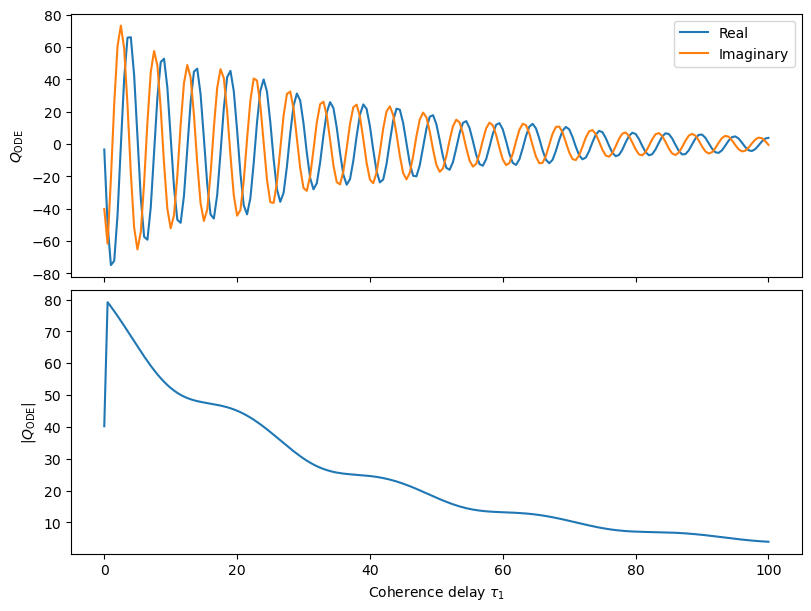

In [77]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(8, 6),
    sharex=True,
    constrained_layout=True
)

axes[0].plot(
    tau_grid,
    np.real(Q_ode_grid),
    label="Real"
)

axes[0].plot(
    tau_grid,
    np.imag(Q_ode_grid),
    label="Imaginary"
)

axes[0].set_ylabel(
    r"$Q_{\mathrm{ODE}}$"
)

axes[0].legend()

axes[1].plot(
    tau_grid,
    np.abs(Q_ode_grid)
)

axes[1].set_xlabel(
    r"Coherence delay $\tau_1$"
)

axes[1].set_ylabel(
    r"$|Q_{\mathrm{ODE}}|$"
)

plt.show()

In [78]:
dtau = (
    tau_grid[1]
    - tau_grid[0]
)

w_tau = np.ones_like(
    tau_grid
)

w_tau[[0, -1]] = 0.5
w_tau *= dtau

fourier_tau = np.exp(
    (
        1j * omega1_target
        - eta
    )
    * tau_grid
)

P_ode_target = np.sum(
    w_tau
    * fourier_tau
    * Q_ode_grid
)

print(
    "dtau =",
    dtau
)

print()
print(
    "P_ODE target =",
    P_ode_target
)

print(
    "|P_ODE target| =",
    abs(P_ode_target)
)

print()
print(
    "P_short target =",
    P_short_target
)

print(
    "|P_short target| =",
    abs(P_short_target)
)

dtau = 0.5

P_ODE target = (-97.95728512553207-1516.0156565421853j)
|P_ODE target| = 1519.177112976034

P_short target = (-99.11265809586664-1537.7372287311982j)
|P_short target| = 1540.928000790671


In [79]:
error_ode_short = (
    abs(
        P_ode_target
        - P_short_target
    )
    /
    abs(P_ode_target)
)

amplitude_ratio_ode_short = (
    abs(P_ode_target)
    / abs(P_short_target)
)

phase_ode_short = np.angle(
    P_ode_target
    / P_short_target
)

print()
print(
    "ODE vs short-pulse relative error =",
    error_ode_short
)

print(
    "ODE vs short-pulse error (%) =",
    100.0 * error_ode_short
)

print()
print(
    "|P_ODE| / |P_short| =",
    amplitude_ratio_ode_short
)

print(
    "phase difference (deg) =",
    np.degrees(
        phase_ode_short
    )
)


ODE vs short-pulse relative error = 0.014318460640621125
ODE vs short-pulse error (%) = 1.4318460640621125

|P_ODE| / |P_short| = 0.9858845528126712
phase difference (deg) = -0.009208245865241696


### 11.2 Control of the coherence-delay Fourier transform

Before interpreting the ODE--short-pulse discrepancy as a physical
finite-pulse effect, we quantify the numerical error introduced by the
finite coherence-delay window and trapezoidal quadrature.

For the impulsive nonrephasing response at fixed detection frequency,

$$
Q_{\mathrm{imp}}(\omega_3,T,\tau_1)
=
\langle\!\langle\mu|
G_{\eta}(\omega_3)
V_{\uparrow}
e^{\mathcal{L}T}
V_{\downarrow}
e^{\mathcal{L}\tau_1}
V_{\uparrow}
|\rho_{\mathrm{ss}}\rangle\rangle.
$$

Its exact infinite-time transform is

$$
\int_0^\infty d\tau_1\,
e^{(i\omega_1-\eta)\tau_1}
Q_{\mathrm{imp}}(\omega_3,T,\tau_1)
=
M_{NR}^{(3)}(\omega_3,T,\omega_1).
$$

We evaluate the left-hand side using exactly the same
$\tau_1$ grid and quadrature used for the driven ODE.  The resulting
difference from the resolvent therefore measures only numerical
truncation and quadrature error.

In [80]:
Q_imp_grid = np.zeros(
    N_tau,
    dtype=complex
)

x_initial = (
    V_up
    @ rho_ss_vec
)

for i, tau1 in enumerate(tau_grid):

    x = (
        expm(
            L_super * tau1
        )
        @ x_initial
    )

    x = (
        V_down
        @ x
    )

    x = (
        prop_T
        @ x
    )

    x = (
        V_up
        @ x
    )

    x = np.linalg.solve(
        A3_target,
        x
    )

    Q_imp_grid[i] = (
        mu_bra
        @ x
    )

In [81]:
M_NR_numerical_tau = np.sum(
    w_tau
    * fourier_tau
    * Q_imp_grid
)

print(
    "M_NR exact resolvent =",
    M_NR_target
)

print(
    "M_NR same-grid transform =",
    M_NR_numerical_tau
)

print()

transform_error = (
    abs(
        M_NR_numerical_tau
        - M_NR_target
    )
    /
    abs(M_NR_target)
)

print(
    "tau-grid transform error =",
    transform_error
)

print(
    "tau-grid transform error (%) =",
    100.0 * transform_error
)

M_NR exact resolvent = (-99.14239635381105-1538.1986191049132j)
M_NR same-grid transform = (-98.3686962188778-1526.5119228308179j)

tau-grid transform error = 0.007598515918096802
tau-grid transform error (%) = 0.7598515918096802


In [82]:
P_short_same_grid = (
    E1_target
    * E2_target
    * E3_target
    * M_NR_numerical_tau
)

error_ode_same_grid = (
    abs(
        P_ode_target
        - P_short_same_grid
    )
    /
    abs(P_ode_target)
)

amplitude_ratio_same_grid = (
    abs(P_ode_target)
    / abs(P_short_same_grid)
)

phase_same_grid = np.angle(
    P_ode_target
    / P_short_same_grid
)

print(
    "P_ODE =",
    P_ode_target
)

print(
    "P_short, infinite-time =",
    P_short_target
)

print(
    "P_short, same tau grid =",
    P_short_same_grid
)

print()

print(
    "ODE vs same-grid short-pulse error =",
    error_ode_same_grid
)

print(
    "ODE vs same-grid short-pulse error (%) =",
    100.0 * error_ode_same_grid
)

print()

print(
    "|P_ODE| / |P_short_same_grid| =",
    amplitude_ratio_same_grid
)

print(
    "phase difference (deg) =",
    np.degrees(
        phase_same_grid
    )
)

P_ODE = (-97.95728512553207-1516.0156565421853j)
P_short, infinite-time = (-99.11265809586664-1537.7372287311982j)
P_short, same tau grid = (-98.33919003616084-1526.0540379401364j)

ODE vs same-grid short-pulse error = 0.006612555817563755
ODE vs same-grid short-pulse error (%) = 0.6612555817563756

|P_ODE| / |P_short_same_grid| = 0.9934331589369166
phase difference (deg) = -0.009972667282626024


### 11.3 Refined sampling of the pulse-overlap region

The previous ODE calculations used a uniform coherence-delay spacing

$$
\Delta\tau_1=0.5.
$$

For narrow pulses, the pulse-overlap region close to $\tau_1=0$ can be
much narrower than this spacing.  We therefore perform a second,
independent numerical test using dense sampling near zero delay while
retaining the coarser grid at long times.

All previous calculations are retained unchanged for comparison.

In [83]:
# Refined ODE test.
# Keep all previous tau-grid calculations unchanged.

sigma_refined = 0.1

tau_max_refined = 100.0

tau_dense_end_refined = 2.0
dtau_dense_refined = 0.05
dtau_tail_refined = 0.5

tau_dense_refined = np.arange(
    0.0,
    tau_dense_end_refined + 0.5 * dtau_dense_refined,
    dtau_dense_refined
)

tau_tail_refined = np.arange(
    tau_dense_end_refined + dtau_tail_refined,
    tau_max_refined + 0.5 * dtau_tail_refined,
    dtau_tail_refined
)

tau_grid_refined = np.concatenate([
    tau_dense_refined,
    tau_tail_refined,
])

N_tau_refined = len(
    tau_grid_refined
)

Q_ode_refined = np.zeros(
    N_tau_refined,
    dtype=complex
)

for i, tau1 in enumerate(
    tau_grid_refined
):

    Q_ode_refined[i] = NR_ODE_detection_at_tau(
        tau1,
        sigma_refined,
        omega_L_ode,
        omega3_target,
    )

    if (
        i % 20 == 0
        or i == N_tau_refined - 1
    ):

        print(
            f"{i:3d}/{N_tau_refined - 1}: "
            f"tau1 = {tau1:.2f}, "
            f"|Q| = {abs(Q_ode_refined[i]):.6f}"
        )

print()
print(
    "sigma =",
    sigma_refined
)

print(
    "number of tau points =",
    N_tau_refined
)

print(
    "dense spacing =",
    dtau_dense_refined
)

print(
    "tail spacing =",
    dtau_tail_refined
)

  0/236: tau1 = 0.00, |Q| = 40.218936
 20/236: tau1 = 1.00, |Q| = 77.825948
 40/236: tau1 = 2.00, |Q| = 74.887560
 60/236: tau1 = 12.00, |Q| = 49.539675
 80/236: tau1 = 22.00, |Q| = 42.933804
100/236: tau1 = 32.00, |Q| = 27.661232
120/236: tau1 = 42.00, |Q| = 23.921270
140/236: tau1 = 52.00, |Q| = 16.059162
160/236: tau1 = 62.00, |Q| = 13.001342
180/236: tau1 = 72.00, |Q| = 9.503073
200/236: tau1 = 82.00, |Q| = 6.971192
220/236: tau1 = 92.00, |Q| = 5.603363
236/236: tau1 = 100.00, |Q| = 3.909675

sigma = 0.1
number of tau points = 237
dense spacing = 0.05
tail spacing = 0.5


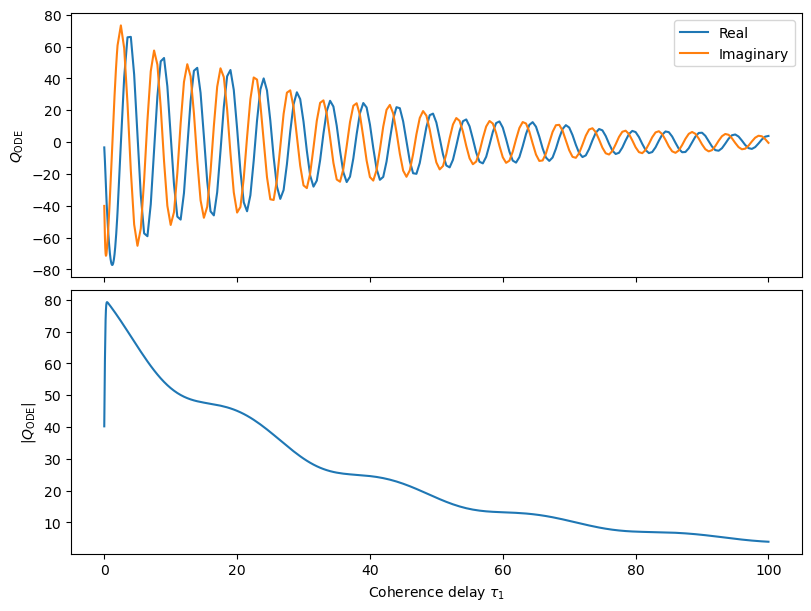

In [84]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(8, 6),
    sharex=True,
    constrained_layout=True
)

axes[0].plot(
    tau_grid_refined,
    np.real(Q_ode_refined),
    label="Real"
)

axes[0].plot(
    tau_grid_refined,
    np.imag(Q_ode_refined),
    label="Imaginary"
)

axes[0].set_ylabel(
    r"$Q_{\mathrm{ODE}}$"
)

axes[0].legend()


axes[1].plot(
    tau_grid_refined,
    np.abs(Q_ode_refined)
)

axes[1].set_xlabel(
    r"Coherence delay $\tau_1$"
)

axes[1].set_ylabel(
    r"$|Q_{\mathrm{ODE}}|$"
)

plt.show()

In [85]:
fourier_tau_refined = np.exp(
    (
        1j * omega1_target
        - eta
    )
    * tau_grid_refined
)

P_ode_refined = np.trapezoid(
    fourier_tau_refined
    * Q_ode_refined,
    x=tau_grid_refined
)

print(
    "P_ODE refined =",
    P_ode_refined
)

print(
    "|P_ODE refined| =",
    abs(P_ode_refined)
)

P_ODE refined = (-98.28863969241955-1521.5173442451608j)
|P_ODE refined| = 1524.6887175851448


In [86]:
Q_imp_refined = np.zeros(
    N_tau_refined,
    dtype=complex
)

x_initial_refined = (
    V_up
    @ rho_ss_vec
)

for i, tau1 in enumerate(
    tau_grid_refined
):

    x = (
        expm(
            L_super * tau1
        )
        @ x_initial_refined
    )

    x = (
        V_down
        @ x
    )

    x = (
        prop_T
        @ x
    )

    x = (
        V_up
        @ x
    )

    x = np.linalg.solve(
        A3_target,
        x
    )

    Q_imp_refined[i] = (
        mu_bra
        @ x
    )


M_NR_refined_grid = np.trapezoid(
    fourier_tau_refined
    * Q_imp_refined,
    x=tau_grid_refined
)

transform_error_refined = (
    abs(
        M_NR_refined_grid
        - M_NR_target
    )
    /
    abs(M_NR_target)
)

print(
    "M_NR exact resolvent =",
    M_NR_target
)

print(
    "M_NR refined-grid transform =",
    M_NR_refined_grid
)

print()

print(
    "refined tau-grid error =",
    transform_error_refined
)

print(
    "refined tau-grid error (%) =",
    100.0
    * transform_error_refined
)

M_NR exact resolvent = (-99.14239635381105-1538.1986191049132j)
M_NR refined-grid transform = (-98.3579242817347-1526.517663418498j)

refined tau-grid error = 0.0075952648414720735
refined tau-grid error (%) = 0.7595264841472074


In [87]:
E1_refined = np.exp(
    -0.5
    * sigma_refined**2
    * (
        omega1_target
        - omega_L_ode
    )**2
)

E2_refined = np.exp(
    -0.5
    * sigma_refined**2
    * (
        omega1_target
        - omega_L_ode
    )**2
)

E3_refined = np.exp(
    -0.5
    * sigma_refined**2
    * (
        omega3_target
        - omega_L_ode
    )**2
)

P_short_refined_grid = (
    E1_refined
    * E2_refined
    * E3_refined
    * M_NR_refined_grid
)

error_ode_refined = (
    abs(
        P_ode_refined
        - P_short_refined_grid
    )
    /
    abs(P_ode_refined)
)

amplitude_ratio_refined = (
    abs(P_ode_refined)
    / abs(P_short_refined_grid)
)

phase_refined = np.angle(
    P_ode_refined
    / P_short_refined_grid
)

print(
    "P_ODE refined =",
    P_ode_refined
)

print(
    "P_short refined-grid =",
    P_short_refined_grid
)

print()

print(
    "ODE vs refined-grid short-pulse error =",
    error_ode_refined
)

print(
    "ODE vs refined-grid short-pulse error (%) =",
    100.0
    * error_ode_refined
)

print()

print(
    "|P_ODE| / |P_short_refined| =",
    amplitude_ratio_refined
)

print(
    "phase difference (deg) =",
    np.degrees(
        phase_refined
    )
)

P_ODE refined = (-98.28863969241955-1521.5173442451608j)
P_short refined-grid = (-98.3284213301142-1526.0597768058985j)

ODE vs refined-grid short-pulse error = 0.002979366676276952
ODE vs refined-grid short-pulse error (%) = 0.2979366676276952

|P_ODE| / |P_short_refined| = 0.997034071627809
phase difference (deg) = -0.009483993604467765


### 11.4 Effect of pulse overlap

The refined-grid ODE calculation still differs from the scalar
short-pulse result by approximately $0.30\%$ at $\sigma=0.1$.

The separated-pulse convolution predicts a substantially smaller
finite-width correction at the same spectral point.  The remaining
difference may therefore originate primarily from the region near

$$
\tau_1=0,
$$

where pulses 1 and 2 overlap.

To test this directly, we repeat the frequency integration using the
already-computed ODE data while excluding short coherence delays.

The ODE and impulsive reference are truncated at exactly the same lower
limit, so the comparison continues to use identical numerical
quadrature and time windows.

In [88]:
tau_cut_values = np.array([
    0.0,
    0.2,
    0.4,
    0.6,
    0.8,
    1.0,
])

overlap_cut_errors = []

for tau_cut in tau_cut_values:

    mask = (
        tau_grid_refined
        >= tau_cut
    )

    tau_cut_grid = (
        tau_grid_refined[mask]
    )

    fourier_cut = (
        fourier_tau_refined[mask]
    )

    # Direct finite-pulse ODE
    P_ode_cut = np.trapezoid(
        fourier_cut
        * Q_ode_refined[mask],
        x=tau_cut_grid
    )

    # Impulsive molecular response on exactly
    # the same truncated tau grid
    M_imp_cut = np.trapezoid(
        fourier_cut
        * Q_imp_refined[mask],
        x=tau_cut_grid
    )

    # Scalar short-pulse prediction subjected
    # to the same lower and upper time limits
    P_short_cut = (
        E1_refined
        * E2_refined
        * E3_refined
        * M_imp_cut
    )

    error_cut = (
        abs(
            P_ode_cut
            - P_short_cut
        )
        /
        abs(P_ode_cut)
    )

    overlap_cut_errors.append(
        error_cut
    )

    print(
        f"tau_cut = {tau_cut:4.2f}   "
        f"error = {100.0*error_cut:.6f} %"
    )

overlap_cut_errors = np.array(
    overlap_cut_errors
)

tau_cut = 0.00   error = 0.297937 %
tau_cut = 0.20   error = 0.027578 %
tau_cut = 0.40   error = 0.011019 %
tau_cut = 0.60   error = 0.011115 %
tau_cut = 0.80   error = 0.011122 %
tau_cut = 1.00   error = 0.011127 %


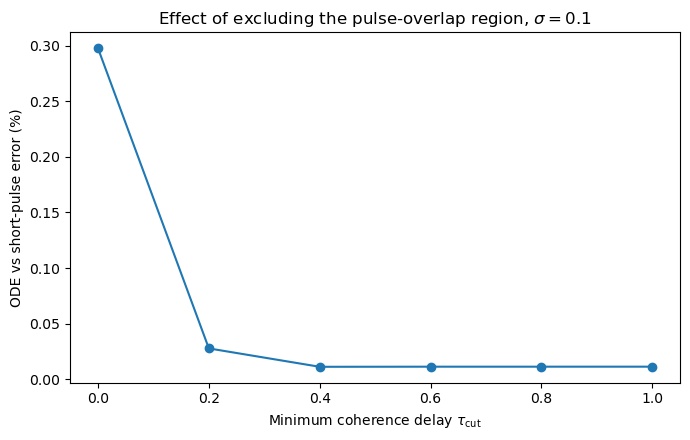

In [89]:
plt.figure(
    figsize=(7, 4.5)
)

plt.plot(
    tau_cut_values,
    100.0 * overlap_cut_errors,
    "o-"
)

plt.xlabel(
    r"Minimum coherence delay $\tau_{\mathrm{cut}}$"
)

plt.ylabel(
    "ODE vs short-pulse error (%)"
)

plt.title(
    r"Effect of excluding the pulse-overlap region, $\sigma=0.1$"
)

plt.tight_layout()
plt.show()

## 12. ODE validation as a function of pulse width

We now compare the directly driven finite-pulse ODE with the scalar
short-pulse expression for several Gaussian pulse widths,

$$
\sigma
=
0.05,\ 0.10,\ 0.20,\ 0.30,\ 0.40.
$$

The comparison is performed at the upper-upper nonrephasing resonance,

$$
\omega_1
=
\omega_3
=
\Omega_+.
$$

For each pulse width we calculate two errors.

The full-scan error includes all coherence delays,

$$
\tau_1\ge0,
$$

and therefore includes the pulse-overlap region.

The separated-pulse error uses only

$$
\tau_1\ge4\sigma,
$$

where the overlap between pulses 1 and 2 is strongly suppressed.

Both the ODE response and the scalar short-pulse reference are
integrated over exactly the same numerical time grid in each
comparison.

In [90]:
def run_sigma_ode_test(
    sigma_test,
    tau_max_test=100.0,
):

    # Resolve the pulse-overlap region more finely.
    #
    # For sigma = 0.05 we use dt = 0.025.
    # For the larger widths we use dt = 0.05.

    dt_dense = min(
        0.05,
        sigma_test / 2.0
    )

    # Follow the overlap region to at least 6 sigma.
    dense_end = max(
        2.0,
        6.0 * sigma_test
    )

    tau_cut = (
        4.0 * sigma_test
    )

    tau_dense = np.arange(
        0.0,
        dense_end + 0.5 * dt_dense,
        dt_dense
    )

    tau_tail = np.arange(
        dense_end + 0.5,
        tau_max_test + 0.25,
        0.5
    )

    # Include tau_cut exactly in the grid.
    tau_test_grid = np.unique(
        np.concatenate([
            tau_dense,
            tau_tail,
            np.array([tau_cut]),
        ])
    )

    N_test = len(
        tau_test_grid
    )

    # ------------------------------------------------
    # Direct finite-pulse ODE
    # ------------------------------------------------

    Q_ode_test = np.zeros(
        N_test,
        dtype=complex
    )

    for i, tau1 in enumerate(
        tau_test_grid
    ):

        Q_ode_test[i] = (
            NR_ODE_detection_at_tau(
                tau1,
                sigma_test,
                omega_L_ode,
                omega3_target,
            )
        )

    # ------------------------------------------------
    # Impulsive reference on exactly the same grid
    # ------------------------------------------------

    Q_imp_test = np.zeros(
        N_test,
        dtype=complex
    )

    x_initial_test = (
        V_up
        @ rho_ss_vec
    )

    for i, tau1 in enumerate(
        tau_test_grid
    ):

        x = (
            expm(
                L_super * tau1
            )
            @ x_initial_test
        )

        x = (
            V_down
            @ x
        )

        x = (
            prop_T
            @ x
        )

        x = (
            V_up
            @ x
        )

        x = np.linalg.solve(
            A3_target,
            x
        )

        Q_imp_test[i] = (
            mu_bra
            @ x
        )

    # ------------------------------------------------
    # Pulse spectral factors
    # ------------------------------------------------

    E1_test = np.exp(
        -0.5
        * sigma_test**2
        * (
            omega1_target
            - omega_L_ode
        )**2
    )

    E2_test = np.exp(
        -0.5
        * sigma_test**2
        * (
            omega1_target
            - omega_L_ode
        )**2
    )

    E3_test = np.exp(
        -0.5
        * sigma_test**2
        * (
            omega3_target
            - omega_L_ode
        )**2
    )

    pulse_factor_test = (
        E1_test
        * E2_test
        * E3_test
    )

    fourier_test = np.exp(
        (
            1j * omega1_target
            - eta
        )
        * tau_test_grid
    )

    # =================================================
    # FULL SCAN: tau1 >= 0
    # =================================================

    P_ode_full = np.trapezoid(
        fourier_test
        * Q_ode_test,
        x=tau_test_grid
    )

    M_imp_full = np.trapezoid(
        fourier_test
        * Q_imp_test,
        x=tau_test_grid
    )

    P_short_full = (
        pulse_factor_test
        * M_imp_full
    )

    error_full = (
        abs(
            P_ode_full
            - P_short_full
        )
        /
        abs(P_ode_full)
    )

    # =================================================
    # SEPARATED SCAN: tau1 >= 4 sigma
    # =================================================

    mask_sep = (
        tau_test_grid
        >= tau_cut
    )

    tau_sep = (
        tau_test_grid[mask_sep]
    )

    fourier_sep = (
        fourier_test[mask_sep]
    )

    P_ode_sep = np.trapezoid(
        fourier_sep
        * Q_ode_test[mask_sep],
        x=tau_sep
    )

    M_imp_sep = np.trapezoid(
        fourier_sep
        * Q_imp_test[mask_sep],
        x=tau_sep
    )

    P_short_sep = (
        pulse_factor_test
        * M_imp_sep
    )

    error_sep = (
        abs(
            P_ode_sep
            - P_short_sep
        )
        /
        abs(P_ode_sep)
    )

    return {
        "sigma": sigma_test,
        "tau_cut": tau_cut,
        "N_tau": N_test,
        "dt_dense": dt_dense,
        "P_ode_full": P_ode_full,
        "P_short_full": P_short_full,
        "error_full": error_full,
        "P_ode_sep": P_ode_sep,
        "P_short_sep": P_short_sep,
        "error_sep": error_sep,
    }

In [91]:
sigma_ode_values = np.array([
    0.05,
    0.10,
    0.20,
    0.30,
    0.40,
])

sigma_ode_results = []

for sigma_i in sigma_ode_values:

    print()
    print(
        "Running sigma =",
        sigma_i
    )

    result_i = run_sigma_ode_test(
        sigma_i
    )

    sigma_ode_results.append(
        result_i
    )

    print(
        "  tau_cut =",
        result_i["tau_cut"]
    )

    print(
        "  N_tau =",
        result_i["N_tau"]
    )

    print(
        "  full error (%) =",
        100.0
        * result_i["error_full"]
    )

    print(
        "  separated error (%) =",
        100.0
        * result_i["error_sep"]
    )


Running sigma = 0.05
  tau_cut = 0.2
  N_tau = 277
  full error (%) = 0.14946085377933205
  separated error (%) = 0.002728479602018515

Running sigma = 0.1
  tau_cut = 0.4
  N_tau = 237
  full error (%) = 0.2979366676276952
  separated error (%) = 0.011018711574550585

Running sigma = 0.2
  tau_cut = 0.8
  N_tau = 237
  full error (%) = 0.5886070931854572
  separated error (%) = 0.04437498397909734

Running sigma = 0.3
  tau_cut = 1.2
  N_tau = 238
  full error (%) = 0.8807004199514165
  separated error (%) = 0.10012438187200154

Running sigma = 0.4
  tau_cut = 1.6
  N_tau = 244
  full error (%) = 1.1764801557178672
  separated error (%) = 0.17830132240821006


In [92]:
full_errors_sigma = np.array([
    result["error_full"]
    for result in sigma_ode_results
])

separated_errors_sigma = np.array([
    result["error_sep"]
    for result in sigma_ode_results
])

print(
    f"{'sigma':>8s}"
    f"{'4 sigma':>12s}"
    f"{'full error (%)':>20s}"
    f"{'separated error (%)':>24s}"
)

for result in sigma_ode_results:

    print(
        f"{result['sigma']:8.3f}"
        f"{result['tau_cut']:12.3f}"
        f"{100.0*result['error_full']:20.6f}"
        f"{100.0*result['error_sep']:24.6f}"
    )

   sigma     4 sigma      full error (%)     separated error (%)
   0.050       0.200            0.149461                0.002728
   0.100       0.400            0.297937                0.011019
   0.200       0.800            0.588607                0.044375
   0.300       1.200            0.880700                0.100124
   0.400       1.600            1.176480                0.178301


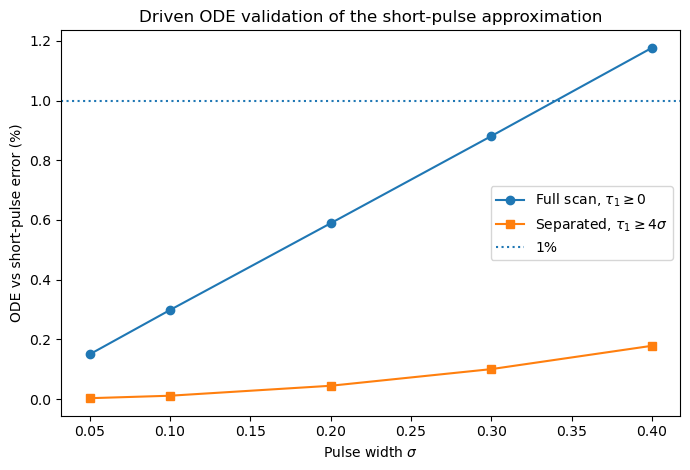

In [93]:
plt.figure(
    figsize=(7, 4.8)
)

plt.plot(
    sigma_ode_values,
    100.0 * full_errors_sigma,
    "o-",
    label=r"Full scan, $\tau_1\geq0$"
)

plt.plot(
    sigma_ode_values,
    100.0 * separated_errors_sigma,
    "s-",
    label=r"Separated, $\tau_1\geq4\sigma$"
)

plt.axhline(
    1.0,
    linestyle=":",
    label="1%"
)

plt.xlabel(
    r"Pulse width $\sigma$"
)

plt.ylabel(
    "ODE vs short-pulse error (%)"
)

plt.title(
    "Driven ODE validation of the short-pulse approximation"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    figures_dir
    / "short_pulse_ode_validation_vs_sigma.pdf",
    bbox_inches="tight"
)

plt.show()

In [94]:
# Scaling exponents of the driven-ODE validation

slope_full, _ = np.polyfit(
    np.log(sigma_ode_values),
    np.log(full_errors_sigma),
    1
)

slope_sep, _ = np.polyfit(
    np.log(sigma_ode_values),
    np.log(separated_errors_sigma),
    1
)

print(
    "Full-scan scaling exponent =",
    slope_full
)

print(
    "Separated-pulse scaling exponent =",
    slope_sep
)

Full-scan scaling exponent = 0.9906503717230584
Separated-pulse scaling exponent = 2.0099896520585814


## 13. Full two-dimensional ODE spectrum

We now construct an explicit two-dimensional nonrephasing spectrum
from the driven finite-pulse ODE at

$$
\sigma=0.4.
$$

The ODE is propagated once for each coherence delay $\tau_1$.
For each propagation, the complete detection-frequency axis
$\omega_3$ is obtained from the same time-domain trajectory.

The final $\tau_1$ dependence is then Fourier transformed to obtain
the $\omega_1$ axis.

We compare three spectra:

1. The directly driven finite-pulse ODE spectrum,

$$
P_{\mathrm{ODE}}^{(3)}(\omega_3,T,\omega_1).
$$

2. The scalar short-pulse frequency-domain prediction,

$$
P_{\mathrm{short}}^{(3)}
=
E_3(\omega_3)
E_2(-\omega_1)
E_1(\omega_1)
M_{NR}^{(3)}.
$$

3. The impulsive molecular response,

$$
M_{NR}^{(3)}(\omega_3,T,\omega_1).
$$

This comparison shows directly how the finite-pulse experiment departs
from both the short-pulse approximation and the impulsive limit.

In [95]:
sigma_2d = 0.4
tau_max_2d = 150.0

omega1_2d = omega1_grid.copy()
omega3_2d = omega3_grid.copy()

# Precompute the frequency-domain detector rows
#
# detector_rows_2d[i] @ rho
#
# is equivalent to
#
# mu_bra @ G(omega3_i) @ rho

detector_rows_2d = np.zeros(
    (
        len(omega3_2d),
        d**2,
    ),
    dtype=complex,
)

for i3, omega3 in enumerate(
    omega3_2d
):

    A3_i = (
        (eta - 1j * omega3) * I16
        - L_super
    )

    detector_rows_2d[i3] = np.linalg.solve(
        A3_i.T,
        mu_bra
    )

print(
    "sigma_2d =",
    sigma_2d
)

print(
    "omega1 points =",
    len(omega1_2d)
)

print(
    "omega3 points =",
    len(omega3_2d)
)

print(
    "tau_max =",
    tau_max_2d
)

sigma_2d = 0.4
omega1 points = 201
omega3 points = 201
tau_max = 150.0


In [96]:
def NR_ODE_detection_spectrum_at_tau(
    tau1,
    sigma,
    omega_L,
    omega3_values,
    detector_rows,
    n_sigma=6.0,
):

    nL = d**2

    t1c = 0.0
    t2c = tau1
    t3c = tau1 + T_wait

    t_start = (
        t1c
        - n_sigma * sigma
    )

    t_end = (
        t3c
        + n_sigma * sigma
    )

    y0 = np.zeros(
        3 * nL,
        dtype=complex
    )

    def rhs(t, y):

        rho1 = y[
            0:nL
        ]

        rho2 = y[
            nL:2*nL
        ]

        rho3 = y[
            2*nL:3*nL
        ]

        E1 = gaussian_branch(
            t,
            t1c,
            sigma,
            omega_L,
            +1
        )

        E2 = gaussian_branch(
            t,
            t2c,
            sigma,
            omega_L,
            -1
        )

        E3 = gaussian_branch(
            t,
            t3c,
            sigma,
            omega_L,
            +1
        )

        drho1 = (
            L_super @ rho1
            + E1
            * (
                V_up
                @ rho_ss_vec
            )
        )

        drho2 = (
            L_super @ rho2
            + E2
            * (
                V_down
                @ rho1
            )
        )

        drho3 = (
            L_super @ rho3
            + E3
            * (
                V_up
                @ rho2
            )
        )

        return np.concatenate([
            drho1,
            drho2,
            drho3,
        ])

    sol = solve_ivp(
        rhs,
        (
            t_start,
            t_end,
        ),
        y0,
        method="DOP853",
        rtol=1e-8,
        atol=1e-10,
        max_step=sigma / 4.0,
        dense_output=True,
    )

    # ------------------------------------------------
    # Contribution while pulse 3 is active
    # ------------------------------------------------

    dt3_sample = (
        sigma / 16.0
    )

    t3_offset = np.arange(
        -n_sigma * sigma,
        n_sigma * sigma
        + 0.5 * dt3_sample,
        dt3_sample
    )

    t_detection = (
        t3c
        + t3_offset
    )

    y_detection = sol.sol(
        t_detection
    )

    rho3_detection = y_detection[
        2*nL:3*nL,
        :
    ]

    P_detection = (
        mu_bra
        @ rho3_detection
    )

    phase3 = np.exp(
        (
            1j * omega3_values[:, None]
            - eta
        )
        * t3_offset[None, :]
    )

    Q_during = np.trapezoid(
        phase3
        * P_detection[None, :],
        x=t3_offset,
        axis=1
    )

    # ------------------------------------------------
    # Free-emission tail after pulse 3
    # ------------------------------------------------

    rho3_end = sol.y[
        2*nL:3*nL,
        -1
    ]

    t3_end = (
        t_end
        - t3c
    )

    tail_phase = np.exp(
        (
            1j * omega3_values
            - eta
        )
        * t3_end
    )

    Q_tail = (
        tail_phase
        * (
            detector_rows
            @ rho3_end
        )
    )

    return (
        Q_during
        + Q_tail
    )

In [97]:
tau_dense_end_2d = (
    6.0 * sigma_2d
)

dtau_dense_2d = 0.05
dtau_tail_2d = 0.5

tau_dense_2d = np.arange(
    0.0,
    tau_dense_end_2d
    + 0.5 * dtau_dense_2d,
    dtau_dense_2d
)

tau_tail_2d = np.arange(
    tau_dense_end_2d
    + dtau_tail_2d,
    tau_max_2d
    + 0.25,
    dtau_tail_2d
)

tau_grid_2d = np.concatenate([
    tau_dense_2d,
    tau_tail_2d,
])

N_tau_2d = len(
    tau_grid_2d
)

Q_ode_2d = np.zeros(
    (
        len(omega3_2d),
        N_tau_2d,
    ),
    dtype=complex
)

print(
    "Number of tau points =",
    N_tau_2d
)

for i, tau1 in enumerate(
    tau_grid_2d
):

    Q_ode_2d[:, i] = (
        NR_ODE_detection_spectrum_at_tau(
            tau1,
            sigma_2d,
            omega_L,
            omega3_2d,
            detector_rows_2d,
        )
    )

    if (
        i % 25 == 0
        or i == N_tau_2d - 1
    ):

        print(
            f"{i:3d}/{N_tau_2d - 1}: "
            f"tau1 = {tau1:.2f}"
        )

Number of tau points = 344
  0/343: tau1 = 0.00
 25/343: tau1 = 1.25
 50/343: tau1 = 3.40
 75/343: tau1 = 15.90
100/343: tau1 = 28.40
125/343: tau1 = 40.90
150/343: tau1 = 53.40
175/343: tau1 = 65.90
200/343: tau1 = 78.40
225/343: tau1 = 90.90
250/343: tau1 = 103.40
275/343: tau1 = 115.90
300/343: tau1 = 128.40
325/343: tau1 = 140.90
343/343: tau1 = 149.90


In [98]:
w_tau_2d = np.zeros_like(
    tau_grid_2d
)

w_tau_2d[0] = (
    tau_grid_2d[1]
    - tau_grid_2d[0]
) / 2.0

w_tau_2d[-1] = (
    tau_grid_2d[-1]
    - tau_grid_2d[-2]
) / 2.0

w_tau_2d[1:-1] = (
    tau_grid_2d[2:]
    - tau_grid_2d[:-2]
) / 2.0


phase1_2d = np.exp(
    (
        1j * omega1_2d[:, None]
        - eta
    )
    * tau_grid_2d[None, :]
)


P_ode_2d = (
    Q_ode_2d
    * w_tau_2d[None, :]
) @ phase1_2d.T


print(
    "P_ode_2d shape =",
    P_ode_2d.shape
)

print(
    "max |P_ode_2d| =",
    np.max(
        np.abs(P_ode_2d)
    )
)

P_ode_2d shape = (201, 201)
max |P_ode_2d| = 1518.4496976353776


In [99]:
E1_2d = np.exp(
    -0.5
    * sigma_2d**2
    * (
        omega1_2d
        - omega_L
    )**2
)

E2_2d = np.exp(
    -0.5
    * sigma_2d**2
    * (
        omega1_2d
        - omega_L
    )**2
)

E3_2d = np.exp(
    -0.5
    * sigma_2d**2
    * (
        omega3_2d
        - omega_L
    )**2
)

pulse_filter_2d = (
    E3_2d[:, None]
    * (
        E1_2d
        * E2_2d
    )[None, :]
)

P_short_2d = (
    pulse_filter_2d
    * M_NR
)

P_impulsive_2d = (
    M_NR.copy()
)

In [100]:
error_2d_ode_short = (
    norm(
        P_ode_2d
        - P_short_2d
    )
    /
    norm(P_ode_2d)
)

error_2d_ode_impulsive = (
    norm(
        P_ode_2d
        - P_impulsive_2d
    )
    /
    norm(P_ode_2d)
)

error_2d_short_impulsive = (
    norm(
        P_short_2d
        - P_impulsive_2d
    )
    /
    norm(P_short_2d)
)

print(
    "ODE vs short-pulse 2D error (%) =",
    100.0
    * error_2d_ode_short
)

print(
    "ODE vs impulsive 2D error (%) =",
    100.0
    * error_2d_ode_impulsive
)

print(
    "Short-pulse vs impulsive 2D difference (%) =",
    100.0
    * error_2d_short_impulsive
)

ODE vs short-pulse 2D error (%) = 2.759305684885748
ODE vs impulsive 2D error (%) = 3.051458092175472
Short-pulse vs impulsive 2D difference (%) = 0.7184452727784458


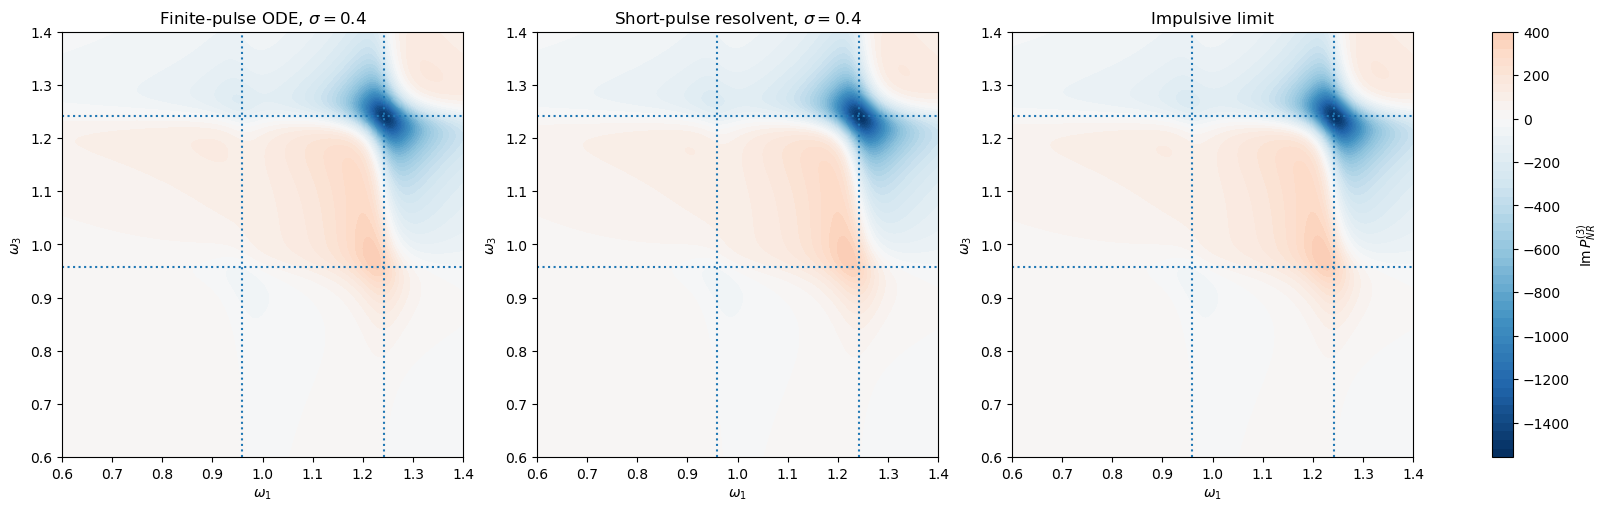

In [101]:
vmax_2d = max(
    np.max(
        np.abs(
            np.imag(P_ode_2d)
        )
    ),
    np.max(
        np.abs(
            np.imag(P_short_2d)
        )
    ),
    np.max(
        np.abs(
            np.imag(P_impulsive_2d)
        )
    ),
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5),
    constrained_layout=True
)

maps_2d = [
    np.imag(P_ode_2d),
    np.imag(P_short_2d),
    np.imag(P_impulsive_2d),
]

titles_2d = [
    r"Finite-pulse ODE, $\sigma=0.4$",
    r"Short-pulse resolvent, $\sigma=0.4$",
    "Impulsive limit",
]

for ax, data, title in zip(
    axes,
    maps_2d,
    titles_2d,
):

    im = ax.contourf(
        omega1_2d,
        omega3_2d,
        data,
        levels=60,
        vmin=-vmax_2d,
        vmax=vmax_2d,
        cmap="RdBu_r"
    )

    ax.axvline(
        omega_minus,
        linestyle=":"
    )

    ax.axvline(
        omega_plus,
        linestyle=":"
    )

    ax.axhline(
        omega_minus,
        linestyle=":"
    )

    ax.axhline(
        omega_plus,
        linestyle=":"
    )

    ax.set_xlabel(
        r"$\omega_1$"
    )

    ax.set_ylabel(
        r"$\omega_3$"
    )

    ax.set_title(
        title
    )

fig.colorbar(
    im,
    ax=axes,
    label=r"$\mathrm{Im}\,P_{NR}^{(3)}$"
)

fig.savefig(
    figures_dir
    / "short_pulse_2d_ode_vs_resolvent_vs_impulsive.pdf",
    bbox_inches="tight"
)

plt.show()

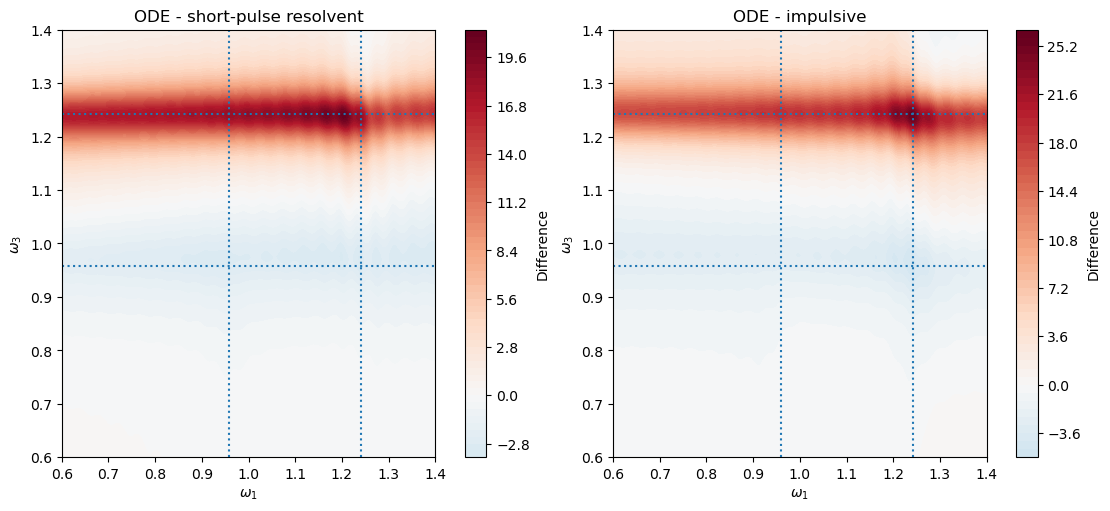

In [102]:
difference_ode_short_2d = (
    np.imag(P_ode_2d)
    - np.imag(P_short_2d)
)

difference_ode_impulsive_2d = (
    np.imag(P_ode_2d)
    - np.imag(P_impulsive_2d)
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 5),
    constrained_layout=True
)

diff1_max = np.max(
    np.abs(
        difference_ode_short_2d
    )
)

diff2_max = np.max(
    np.abs(
        difference_ode_impulsive_2d
    )
)

im1 = axes[0].contourf(
    omega1_2d,
    omega3_2d,
    difference_ode_short_2d,
    levels=60,
    vmin=-diff1_max,
    vmax=diff1_max,
    cmap="RdBu_r"
)

axes[0].set_title(
    "ODE - short-pulse resolvent"
)

im2 = axes[1].contourf(
    omega1_2d,
    omega3_2d,
    difference_ode_impulsive_2d,
    levels=60,
    vmin=-diff2_max,
    vmax=diff2_max,
    cmap="RdBu_r"
)

axes[1].set_title(
    "ODE - impulsive"
)

for ax in axes:

    ax.axvline(
        omega_minus,
        linestyle=":"
    )

    ax.axvline(
        omega_plus,
        linestyle=":"
    )

    ax.axhline(
        omega_minus,
        linestyle=":"
    )

    ax.axhline(
        omega_plus,
        linestyle=":"
    )

    ax.set_xlabel(
        r"$\omega_1$"
    )

    ax.set_ylabel(
        r"$\omega_3$"
    )

fig.colorbar(
    im1,
    ax=axes[0],
    label="Difference"
)

fig.colorbar(
    im2,
    ax=axes[1],
    label="Difference"
)

fig.savefig(
    figures_dir
    / "short_pulse_2d_difference_maps.pdf",
    bbox_inches="tight"
)

plt.show()

## 14. Separated finite pulses with stronger spectral filtering

To make the difference between the short-pulse and impulsive spectra
more visible without introducing strong pulse-overlap effects, we now
use a wider Gaussian pulse,

$$
\sigma=0.8,
$$

while imposing a fixed baseline separation between pulses 1 and 2,

$$
\Delta_{\mathrm{sep}}=4\sigma.
$$

The scanned coherence delay $\tau_1$ is added on top of this baseline
separation, so the pulse centers are

$$
t_{1c}=0,
$$

$$
t_{2c}=\Delta_{\mathrm{sep}}+\tau_1,
$$

and

$$
t_{3c}=\Delta_{\mathrm{sep}}+\tau_1+T.
$$

Thus pulse overlap is strongly suppressed even at $\tau_1=0$.

The corresponding impulsive frequency-domain response is

$$
M_{NR,\Delta}^{(3)}
=
\langle\!\langle\mu|
G_\eta(\omega_3)
V_{\uparrow}
e^{\mathcal{L}T}
V_{\downarrow}
e^{\mathcal{L}\Delta_{\mathrm{sep}}}
G_\eta(\omega_1)
V_{\uparrow}
|\rho_{\mathrm{ss}}\rangle\rangle.
$$

The short-pulse prediction is

$$
P_{NR,\mathrm{short}}^{(3)}
=
E_3^{(+)}(\omega_3)
E_2^{(-)}(-\omega_1)
E_1^{(+)}(\omega_1)
M_{NR,\Delta}^{(3)}.
$$

We compare this directly with the finite-pulse ODE and with the
corresponding impulsive response $M_{NR,\Delta}^{(3)}$.

In [103]:
sigma_demo = 0.8

delay_offset_demo = (
    4.0 * sigma_demo
)

tau_max_demo = 150.0

omega1_demo = omega1_grid.copy()
omega3_demo = omega3_grid.copy()

print(
    "sigma =",
    sigma_demo
)

print(
    "fixed pulse separation =",
    delay_offset_demo
)

print(
    "separation / sigma =",
    delay_offset_demo / sigma_demo
)

sigma = 0.8
fixed pulse separation = 3.2
separation / sigma = 4.0


In [104]:
def NR_ODE_separated_spectrum_at_tau(
    tau1,
    sigma,
    delay_offset,
    omega_L,
    omega3_values,
    detector_rows,
    n_sigma=6.0,
):

    nL = d**2

    t1c = 0.0

    t2c = (
        delay_offset
        + tau1
    )

    t3c = (
        t2c
        + T_wait
    )

    t_start = (
        t1c
        - n_sigma * sigma
    )

    t_end = (
        t3c
        + n_sigma * sigma
    )

    y0 = np.zeros(
        3 * nL,
        dtype=complex
    )

    def rhs(t, y):

        rho1 = y[
            0:nL
        ]

        rho2 = y[
            nL:2*nL
        ]

        rho3 = y[
            2*nL:3*nL
        ]

        E1 = gaussian_branch(
            t,
            t1c,
            sigma,
            omega_L,
            +1
        )

        E2 = gaussian_branch(
            t,
            t2c,
            sigma,
            omega_L,
            -1
        )

        E3 = gaussian_branch(
            t,
            t3c,
            sigma,
            omega_L,
            +1
        )

        drho1 = (
            L_super @ rho1
            + E1
            * (
                V_up @ rho_ss_vec
            )
        )

        drho2 = (
            L_super @ rho2
            + E2
            * (
                V_down @ rho1
            )
        )

        drho3 = (
            L_super @ rho3
            + E3
            * (
                V_up @ rho2
            )
        )

        return np.concatenate([
            drho1,
            drho2,
            drho3,
        ])

    sol = solve_ivp(
        rhs,
        (
            t_start,
            t_end,
        ),
        y0,
        method="DOP853",
        rtol=1e-8,
        atol=1e-10,
        max_step=sigma / 4.0,
        dense_output=True,
    )

    # Detection-time integral while pulse 3 acts

    dt3_sample = (
        sigma / 16.0
    )

    t3_offset = np.arange(
        -n_sigma * sigma,
        n_sigma * sigma
        + 0.5 * dt3_sample,
        dt3_sample
    )

    t_detection = (
        t3c
        + t3_offset
    )

    y_detection = sol.sol(
        t_detection
    )

    rho3_detection = y_detection[
        2*nL:3*nL,
        :
    ]

    P_detection = (
        mu_bra
        @ rho3_detection
    )

    phase3 = np.exp(
        (
            1j * omega3_values[:, None]
            - eta
        )
        * t3_offset[None, :]
    )

    Q_during = np.trapezoid(
        phase3
        * P_detection[None, :],
        x=t3_offset,
        axis=1
    )

    # Free-emission tail

    rho3_end = sol.y[
        2*nL:3*nL,
        -1
    ]

    t3_end = (
        t_end
        - t3c
    )

    tail_phase = np.exp(
        (
            1j * omega3_values
            - eta
        )
        * t3_end
    )

    Q_tail = (
        tail_phase
        * (
            detector_rows
            @ rho3_end
        )
    )

    return (
        Q_during
        + Q_tail
    )

In [105]:
dtau_demo = 0.5

tau_grid_demo = np.arange(
    0.0,
    tau_max_demo
    + 0.5 * dtau_demo,
    dtau_demo
)

N_tau_demo = len(
    tau_grid_demo
)

Q_ode_demo = np.zeros(
    (
        len(omega3_demo),
        N_tau_demo,
    ),
    dtype=complex
)

print(
    "Number of tau points =",
    N_tau_demo
)

for i, tau1 in enumerate(
    tau_grid_demo
):

    Q_ode_demo[:, i] = (
        NR_ODE_separated_spectrum_at_tau(
            tau1,
            sigma_demo,
            delay_offset_demo,
            omega_L,
            omega3_demo,
            detector_rows_2d,
        )
    )

    if (
        i % 25 == 0
        or i == N_tau_demo - 1
    ):

        print(
            f"{i:3d}/{N_tau_demo - 1}: "
            f"tau1 = {tau1:.2f}"
        )

Number of tau points = 301
  0/300: tau1 = 0.00
 25/300: tau1 = 12.50
 50/300: tau1 = 25.00
 75/300: tau1 = 37.50
100/300: tau1 = 50.00
125/300: tau1 = 62.50
150/300: tau1 = 75.00
175/300: tau1 = 87.50
200/300: tau1 = 100.00
225/300: tau1 = 112.50
250/300: tau1 = 125.00
275/300: tau1 = 137.50
300/300: tau1 = 150.00


In [106]:
phase1_demo = np.exp(
    (
        1j * omega1_demo[:, None]
        - eta
    )
    * tau_grid_demo[None, :]
)

P_ode_demo = np.trapezoid(
    Q_ode_demo[:, None, :]
    * phase1_demo[None, :, :],
    x=tau_grid_demo,
    axis=2
)

print(
    "P_ode_demo shape =",
    P_ode_demo.shape
)

print(
    "max |P_ode_demo| =",
    np.max(
        np.abs(P_ode_demo)
    )
)

P_ode_demo shape = (201, 201)
max |P_ode_demo| = 1370.2891010584817


In [107]:
prop_offset_demo = expm(
    L_super
    * delay_offset_demo
)

M_NR_imp_demo = np.zeros(
    (
        len(omega3_demo),
        len(omega1_demo),
    ),
    dtype=complex
)

for i1, omega1_i in enumerate(
    omega1_demo
):

    A1_i = (
        (eta - 1j * omega1_i) * I16
        - L_super
    )

    x = np.linalg.solve(
        A1_i,
        V_up @ rho_ss_vec
    )

    # Fixed extra separation between pulse 1 and pulse 2
    x = (
        prop_offset_demo
        @ x
    )

    x = (
        V_down
        @ x
    )

    x = (
        prop_T
        @ x
    )

    x = (
        V_up
        @ x
    )

    for i3, omega3_i in enumerate(
        omega3_demo
    ):

        A3_i = (
            (eta - 1j * omega3_i) * I16
            - L_super
        )

        y = np.linalg.solve(
            A3_i,
            x
        )

        M_NR_imp_demo[i3, i1] = (
            mu_bra
            @ y
        )

print(
    "max |M_impulsive| =",
    np.max(
        np.abs(M_NR_imp_demo)
    )
)

max |M_impulsive| = 1394.5564200936071


In [108]:
E1_demo = np.exp(
    -0.5
    * sigma_demo**2
    * (
        omega1_demo
        - omega_L
    )**2
)

E2_demo = np.exp(
    -0.5
    * sigma_demo**2
    * (
        omega1_demo
        - omega_L
    )**2
)

E3_demo = np.exp(
    -0.5
    * sigma_demo**2
    * (
        omega3_demo
        - omega_L
    )**2
)

pulse_filter_demo = (
    E3_demo[:, None]
    * (
        E1_demo
        * E2_demo
    )[None, :]
)

P_short_demo = (
    pulse_filter_demo
    * M_NR_imp_demo
)

print(
    "pulse filter min =",
    np.min(
        pulse_filter_demo
    )
)

print(
    "pulse filter max =",
    np.max(
        pulse_filter_demo
    )
)

pulse filter min = 0.7866278610665532
pulse filter max = 1.0


In [109]:
error_demo_ode_short = (
    norm(
        P_ode_demo
        - P_short_demo
    )
    /
    norm(P_ode_demo)
)

error_demo_ode_imp = (
    norm(
        P_ode_demo
        - M_NR_imp_demo
    )
    /
    norm(P_ode_demo)
)

error_demo_short_imp = (
    norm(
        P_short_demo
        - M_NR_imp_demo
    )
    /
    norm(P_short_demo)
)

print(
    "ODE vs short-pulse error (%) =",
    100.0
    * error_demo_ode_short
)

print(
    "ODE vs impulsive error (%) =",
    100.0
    * error_demo_ode_imp
)

print(
    "Short-pulse vs impulsive difference (%) =",
    100.0
    * error_demo_short_imp
)

ODE vs short-pulse error (%) = 1.685082779464583
ODE vs impulsive error (%) = 1.9884012074199813
Short-pulse vs impulsive difference (%) = 2.818713565573038


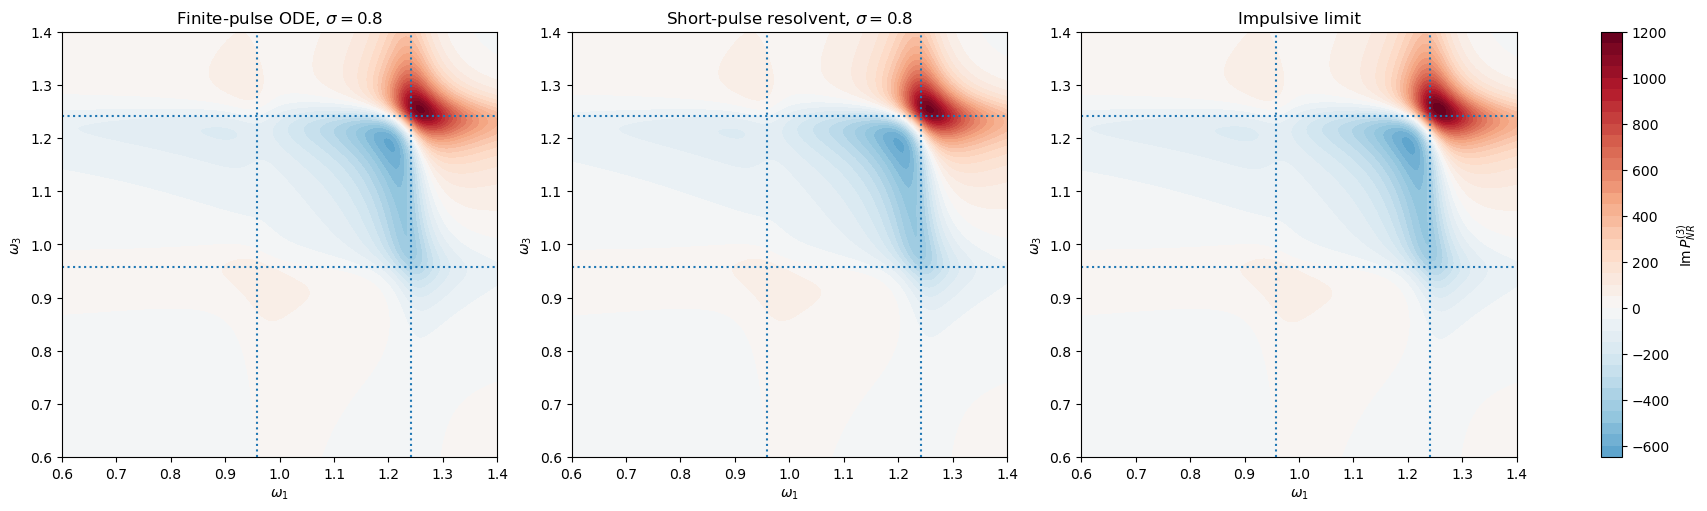

In [110]:
vmax_demo = max(
    np.max(
        np.abs(
            np.imag(P_ode_demo)
        )
    ),
    np.max(
        np.abs(
            np.imag(P_short_demo)
        )
    ),
    np.max(
        np.abs(
            np.imag(M_NR_imp_demo)
        )
    ),
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 5),
    constrained_layout=True
)

demo_maps = [
    np.imag(P_ode_demo),
    np.imag(P_short_demo),
    np.imag(M_NR_imp_demo),
]

demo_titles = [
    r"Finite-pulse ODE, $\sigma=0.8$",
    r"Short-pulse resolvent, $\sigma=0.8$",
    "Impulsive limit",
]

for ax, Z, title in zip(
    axes,
    demo_maps,
    demo_titles,
):

    im = ax.contourf(
        omega1_demo,
        omega3_demo,
        Z,
        levels=40,
        vmin=-vmax_demo,
        vmax=vmax_demo,
        cmap="RdBu_r"
    )

    ax.axvline(
        omega_minus,
        linestyle=":"
    )

    ax.axvline(
        omega_plus,
        linestyle=":"
    )

    ax.axhline(
        omega_minus,
        linestyle=":"
    )

    ax.axhline(
        omega_plus,
        linestyle=":"
    )

    ax.set_xlabel(
        r"$\omega_1$"
    )

    ax.set_ylabel(
        r"$\omega_3$"
    )

    ax.set_title(
        title
    )

fig.colorbar(
    im,
    ax=axes,
    label=r"$\mathrm{Im}\,P_{NR}^{(3)}$"
)

fig.savefig(
    figures_dir
    / "separated_chunky_ode_short_impulsive_sigma08.pdf",
    bbox_inches="tight"
)

plt.show()

## 15. Separated pulses with an upper-exciton-centered carrier

We now use

$$
\sigma=0.4
$$

and suppress pulse overlap by imposing a baseline pulse-center separation

$$
\Delta_{\mathrm{sep}}=4\sigma=1.6.
$$

Unlike the previous centered-carrier calculation, the laser carrier is
placed at the upper exciton,

$$
\omega_L=\Omega_+.
$$

This should preserve good agreement between the finite-pulse ODE and
the short-pulse expression while producing stronger spectral filtering
relative to the impulsive molecular response.

In [111]:
sigma_detuned = 0.4

delay_offset_detuned = (
    4.0 * sigma_detuned
)

omega_L_detuned = omega_plus

tau_max_detuned = 150.0
dtau_detuned = 0.5

omega1_detuned = omega1_grid.copy()
omega3_detuned = omega3_grid.copy()

print("sigma =", sigma_detuned)
print("fixed separation =", delay_offset_detuned)
print("carrier =", omega_L_detuned)
print("separation / sigma =", delay_offset_detuned / sigma_detuned)

sigma = 0.4
fixed separation = 1.6
carrier = 1.2414213562373095
separation / sigma = 4.0


In [112]:
tau_grid_detuned = np.arange(
    0.0,
    tau_max_detuned + 0.5 * dtau_detuned,
    dtau_detuned
)

N_tau_detuned = len(
    tau_grid_detuned
)

Q_ode_detuned = np.zeros(
    (
        len(omega3_detuned),
        N_tau_detuned,
    ),
    dtype=complex
)

for i, tau1 in enumerate(
    tau_grid_detuned
):

    Q_ode_detuned[:, i] = (
        NR_ODE_separated_spectrum_at_tau(
            tau1,
            sigma_detuned,
            delay_offset_detuned,
            omega_L_detuned,
            omega3_detuned,
            detector_rows_2d,
        )
    )

    if (
        i % 25 == 0
        or i == N_tau_detuned - 1
    ):

        print(
            f"{i:3d}/{N_tau_detuned - 1}: "
            f"tau1 = {tau1:.2f}"
        )

  0/300: tau1 = 0.00
 25/300: tau1 = 12.50
 50/300: tau1 = 25.00
 75/300: tau1 = 37.50
100/300: tau1 = 50.00
125/300: tau1 = 62.50
150/300: tau1 = 75.00
175/300: tau1 = 87.50
200/300: tau1 = 100.00
225/300: tau1 = 112.50
250/300: tau1 = 125.00
275/300: tau1 = 137.50
300/300: tau1 = 150.00


In [113]:
phase1_detuned = np.exp(
    (
        1j * omega1_detuned[:, None]
        - eta
    )
    * tau_grid_detuned[None, :]
)

P_ode_detuned = np.trapezoid(
    Q_ode_detuned[:, None, :]
    * phase1_detuned[None, :, :],
    x=tau_grid_detuned,
    axis=2
)

print(
    "P_ode_detuned shape =",
    P_ode_detuned.shape
)

print(
    "max |P_ode_detuned| =",
    np.max(np.abs(P_ode_detuned))
)

P_ode_detuned shape = (201, 201)
max |P_ode_detuned| = 1466.3497194455265


In [114]:
prop_offset_detuned = expm(
    L_super
    * delay_offset_detuned
)

M_NR_imp_detuned = np.zeros(
    (
        len(omega3_detuned),
        len(omega1_detuned),
    ),
    dtype=complex
)

for i1, omega1_i in enumerate(
    omega1_detuned
):

    A1_i = (
        (eta - 1j * omega1_i) * I16
        - L_super
    )

    x = np.linalg.solve(
        A1_i,
        V_up @ rho_ss_vec
    )

    x = (
        prop_offset_detuned
        @ x
    )

    x = (
        V_down
        @ x
    )

    x = (
        prop_T
        @ x
    )

    x = (
        V_up
        @ x
    )

    for i3, omega3_i in enumerate(
        omega3_detuned
    ):

        A3_i = (
            (eta - 1j * omega3_i) * I16
            - L_super
        )

        y = np.linalg.solve(
            A3_i,
            x
        )

        M_NR_imp_detuned[i3, i1] = (
            mu_bra
            @ y
        )

print(
    "max |M_impulsive| =",
    np.max(np.abs(M_NR_imp_detuned))
)

max |M_impulsive| = 1466.4939427158868


In [115]:
E1_detuned = np.exp(
    -0.5
    * sigma_detuned**2
    * (
        omega1_detuned
        - omega_L_detuned
    )**2
)

E2_detuned = np.exp(
    -0.5
    * sigma_detuned**2
    * (
        omega1_detuned
        - omega_L_detuned
    )**2
)

E3_detuned = np.exp(
    -0.5
    * sigma_detuned**2
    * (
        omega3_detuned
        - omega_L_detuned
    )**2
)

pulse_filter_detuned = (
    E3_detuned[:, None]
    * (
        E1_detuned
        * E2_detuned
    )[None, :]
)

P_short_detuned = (
    pulse_filter_detuned
    * M_NR_imp_detuned
)

print(
    "filter min =",
    np.min(pulse_filter_detuned)
)

print(
    "filter max =",
    np.max(pulse_filter_detuned)
)

filter min = 0.905977212069225
filter max = 0.9999995151392649


In [116]:
error_detuned_ode_short = (
    norm(
        P_ode_detuned
        - P_short_detuned
    )
    /
    norm(P_ode_detuned)
)

error_detuned_ode_imp = (
    norm(
        P_ode_detuned
        - M_NR_imp_detuned
    )
    /
    norm(P_ode_detuned)
)

difference_detuned_short_imp = (
    norm(
        P_short_detuned
        - M_NR_imp_detuned
    )
    /
    norm(P_short_detuned)
)

print(
    "ODE vs short-pulse error (%) =",
    100.0 * error_detuned_ode_short
)

print(
    "ODE vs impulsive error (%) =",
    100.0 * error_detuned_ode_imp
)

print(
    "Short-pulse vs impulsive difference (%) =",
    100.0 * difference_detuned_short_imp
)

ODE vs short-pulse error (%) = 0.6181130757337584
ODE vs impulsive error (%) = 0.2964902659793792
Short-pulse vs impulsive difference (%) = 0.7264764287021381


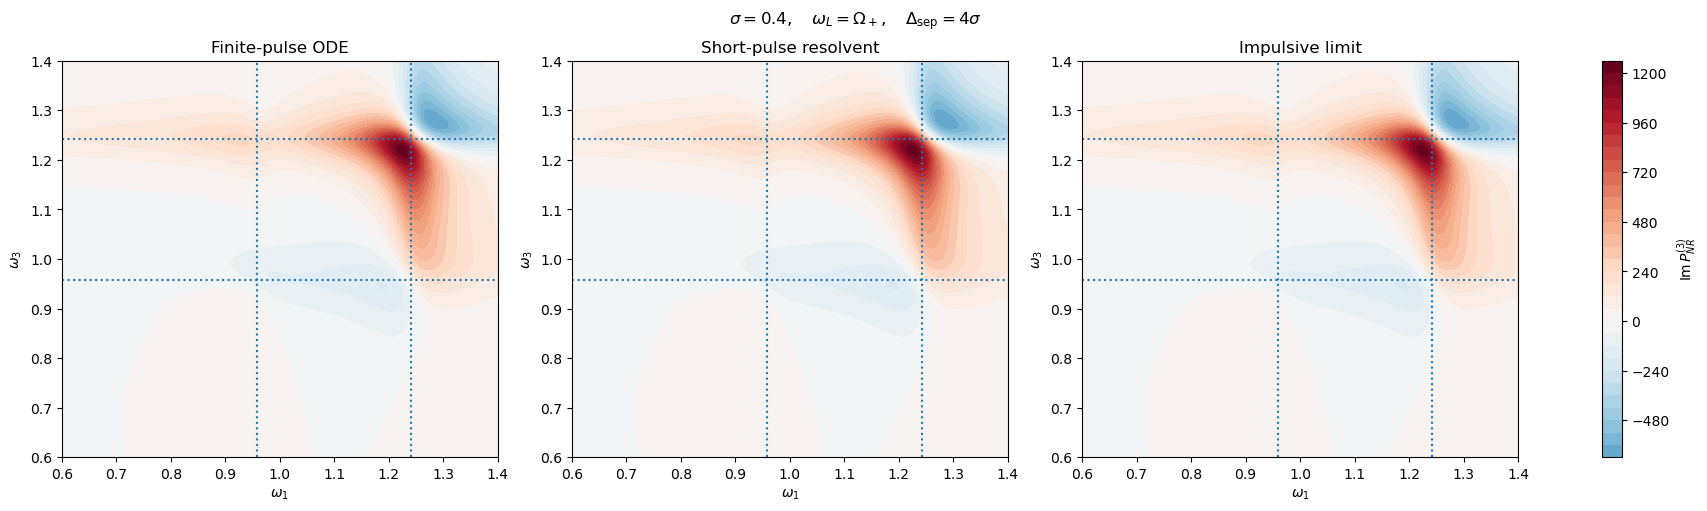

In [117]:
vmax_detuned = max(
    np.max(np.abs(np.imag(P_ode_detuned))),
    np.max(np.abs(np.imag(P_short_detuned))),
    np.max(np.abs(np.imag(M_NR_imp_detuned))),
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 5),
    constrained_layout=True
)

maps_detuned = [
    np.imag(P_ode_detuned),
    np.imag(P_short_detuned),
    np.imag(M_NR_imp_detuned),
]

titles_detuned = [
    r"Finite-pulse ODE",
    r"Short-pulse resolvent",
    r"Impulsive limit",
]

for ax, Z, title in zip(
    axes,
    maps_detuned,
    titles_detuned,
):

    im = ax.contourf(
        omega1_detuned,
        omega3_detuned,
        Z,
        levels=35,
        vmin=-vmax_detuned,
        vmax=vmax_detuned,
        cmap="RdBu_r"
    )

    ax.axvline(
        omega_minus,
        linestyle=":"
    )

    ax.axvline(
        omega_plus,
        linestyle=":"
    )

    ax.axhline(
        omega_minus,
        linestyle=":"
    )

    ax.axhline(
        omega_plus,
        linestyle=":"
    )

    ax.set_xlabel(
        r"$\omega_1$"
    )

    ax.set_ylabel(
        r"$\omega_3$"
    )

    ax.set_title(
        title
    )

fig.colorbar(
    im,
    ax=axes,
    label=r"$\mathrm{Im}\,P_{NR}^{(3)}$"
)

fig.suptitle(
    r"$\sigma=0.4,\quad \omega_L=\Omega_+,\quad \Delta_{\rm sep}=4\sigma$"
)

fig.savefig(
    figures_dir
    / "detuned_separated_ode_short_impulsive_sigma04.pdf",
    bbox_inches="tight"
)

plt.show()

In [118]:
omega_L_scan = np.linspace(
    0.6,
    1.6,
    101
)

short_imp_scan = []

for omega_L_i in omega_L_scan:

    E1_i = np.exp(
        -0.5
        * sigma_detuned**2
        * (omega1_detuned - omega_L_i)**2
    )

    E2_i = np.exp(
        -0.5
        * sigma_detuned**2
        * (omega1_detuned - omega_L_i)**2
    )

    E3_i = np.exp(
        -0.5
        * sigma_detuned**2
        * (omega3_detuned - omega_L_i)**2
    )

    filter_i = (
        E3_i[:, None]
        * (E1_i * E2_i)[None, :]
    )

    P_short_i = (
        filter_i
        * M_NR_imp_detuned
    )

    diff_i = (
        norm(
            P_short_i
            - M_NR_imp_detuned
        )
        /
        norm(P_short_i)
    )

    short_imp_scan.append(
        diff_i
    )

short_imp_scan = np.array(
    short_imp_scan
)

i_best = np.argmax(
    short_imp_scan
)

print(
    "largest difference (%) =",
    100.0 * short_imp_scan[i_best]
)

print(
    "carrier giving largest difference =",
    omega_L_scan[i_best]
)

largest difference (%) = 9.911266800599003
carrier giving largest difference = 0.6


In [ ]:
target_difference = 0.05

i_target = np.argmin(
    np.abs(
        short_imp_scan
        - target_difference
    )
)

omega_L_target_demo = (
    omega_L_scan[i_target]
)

print(
    "target carrier =",
    omega_L_target_demo
)

print(
    "predicted short-pulse vs impulsive difference (%) =",
    100.0 * short_imp_scan[i_target]
)

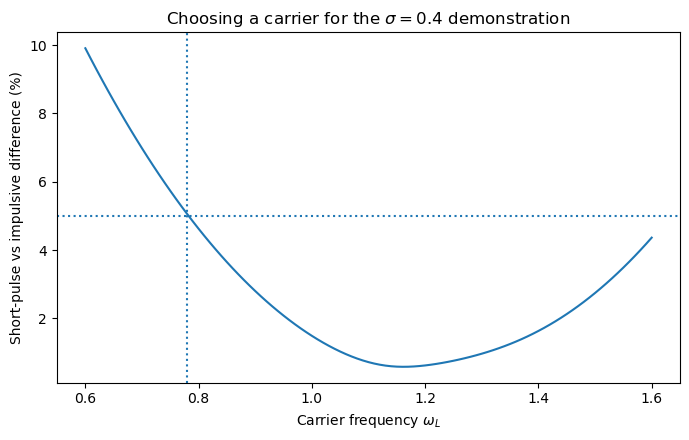

In [120]:
plt.figure(
    figsize=(7, 4.5)
)

plt.plot(
    omega_L_scan,
    100.0 * short_imp_scan
)

plt.axhline(
    5.0,
    linestyle=":"
)

plt.axvline(
    omega_L_target_demo,
    linestyle=":"
)

plt.xlabel(
    r"Carrier frequency $\omega_L$"
)

plt.ylabel(
    "Short-pulse vs impulsive difference (%)"
)

plt.title(
    r"Choosing a carrier for the $\sigma=0.4$ demonstration"
)

plt.tight_layout()
plt.show()

## 16. Selected demonstration with visible spectral filtering

The carrier scan identified

$$
\omega_L=0.78
$$

for $\sigma=0.4$ and $\Delta_{\mathrm{sep}}=4\sigma=1.6$ as a
parameter set for which the scalar short-pulse spectrum differs from
the corresponding impulsive spectrum by approximately $5\%$.

We now perform the directly driven ODE calculation at these parameters
and test whether the ODE remains close to the short-pulse
frequency-domain prediction.

In [122]:
sigma_final_demo = 0.4

delay_final_demo = (
    4.0 * sigma_final_demo
)

omega_L_final_demo = (
    omega_L_target_demo
)

tau_max_final_demo = 150.0
dtau_final_demo = 0.5

tau_grid_final_demo = np.arange(
    0.0,
    tau_max_final_demo + 0.5 * dtau_final_demo,
    dtau_final_demo
)

print(
    "sigma =",
    sigma_final_demo
)

print(
    "fixed separation =",
    delay_final_demo
)

print(
    "carrier frequency =",
    omega_L_final_demo
)

print(
    "number of tau points =",
    len(tau_grid_final_demo)
)

sigma = 0.4
fixed separation = 1.6
carrier frequency = 0.78
number of tau points = 301


In [123]:
Q_ode_final_demo = np.zeros(
    (
        len(omega3_grid),
        len(tau_grid_final_demo),
    ),
    dtype=complex
)

for i, tau1 in enumerate(
    tau_grid_final_demo
):

    Q_ode_final_demo[:, i] = (
        NR_ODE_separated_spectrum_at_tau(
            tau1,
            sigma_final_demo,
            delay_final_demo,
            omega_L_final_demo,
            omega3_grid,
            detector_rows_2d,
        )
    )

    if (
        i % 25 == 0
        or i == len(tau_grid_final_demo) - 1
    ):

        print(
            f"{i:3d}/{len(tau_grid_final_demo)-1}: "
            f"tau1 = {tau1:.2f}"
        )

  0/300: tau1 = 0.00
 25/300: tau1 = 12.50
 50/300: tau1 = 25.00
 75/300: tau1 = 37.50
100/300: tau1 = 50.00
125/300: tau1 = 62.50
150/300: tau1 = 75.00
175/300: tau1 = 87.50
200/300: tau1 = 100.00
225/300: tau1 = 112.50
250/300: tau1 = 125.00
275/300: tau1 = 137.50
300/300: tau1 = 150.00


In [124]:
phase1_final_demo = np.exp(
    (
        1j * omega1_grid[:, None]
        - eta
    )
    * tau_grid_final_demo[None, :]
)

P_ode_final_demo = np.trapezoid(
    Q_ode_final_demo[:, None, :]
    * phase1_final_demo[None, :, :],
    x=tau_grid_final_demo,
    axis=2
)

print(
    "P_ode_final_demo shape =",
    P_ode_final_demo.shape
)

print(
    "max |P_ode_final_demo| =",
    np.max(
        np.abs(P_ode_final_demo)
    )
)

P_ode_final_demo shape = (201, 201)
max |P_ode_final_demo| = 1393.3936500053453


In [125]:
E1_final_demo = np.exp(
    -0.5
    * sigma_final_demo**2
    * (
        omega1_grid
        - omega_L_final_demo
    )**2
)

E2_final_demo = np.exp(
    -0.5
    * sigma_final_demo**2
    * (
        omega1_grid
        - omega_L_final_demo
    )**2
)

E3_final_demo = np.exp(
    -0.5
    * sigma_final_demo**2
    * (
        omega3_grid
        - omega_L_final_demo
    )**2
)

pulse_filter_final_demo = (
    E3_final_demo[:, None]
    * (
        E1_final_demo
        * E2_final_demo
    )[None, :]
)

P_short_final_demo = (
    pulse_filter_final_demo
    * M_NR_imp_detuned
)

print(
    "filter min =",
    np.min(
        pulse_filter_final_demo
    )
)

print(
    "filter max =",
    np.max(
        pulse_filter_final_demo
    )
)

filter min = 0.9118716805121182
filter max = 1.0


In [126]:
error_final_ode_short = (
    norm(
        P_ode_final_demo
        - P_short_final_demo
    )
    /
    norm(P_ode_final_demo)
)

error_final_ode_impulsive = (
    norm(
        P_ode_final_demo
        - M_NR_imp_detuned
    )
    /
    norm(P_ode_final_demo)
)

difference_final_short_impulsive = (
    norm(
        P_short_final_demo
        - M_NR_imp_detuned
    )
    /
    norm(P_short_final_demo)
)

print(
    "ODE vs short-pulse error (%) =",
    100.0
    * error_final_ode_short
)

print(
    "ODE vs impulsive error (%) =",
    100.0
    * error_final_ode_impulsive
)

print(
    "Short-pulse vs impulsive difference (%) =",
    100.0
    * difference_final_short_impulsive
)

ODE vs short-pulse error (%) = 1.3341809424962785
ODE vs impulsive error (%) = 5.095372029421641
Short-pulse vs impulsive difference (%) = 5.050380546014067


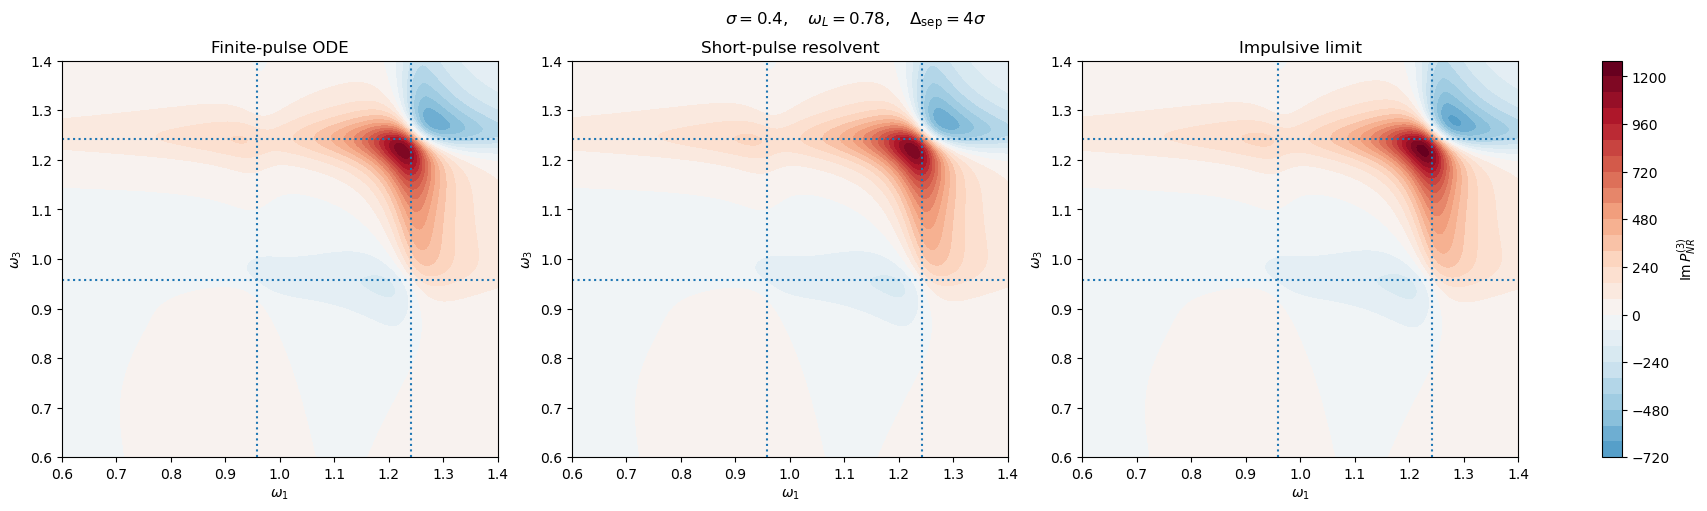

In [127]:
vmax_final_demo = max(
    np.max(
        np.abs(
            np.imag(P_ode_final_demo)
        )
    ),
    np.max(
        np.abs(
            np.imag(P_short_final_demo)
        )
    ),
    np.max(
        np.abs(
            np.imag(M_NR_imp_detuned)
        )
    ),
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 5),
    constrained_layout=True
)

final_maps = [
    np.imag(P_ode_final_demo),
    np.imag(P_short_final_demo),
    np.imag(M_NR_imp_detuned),
]

final_titles = [
    "Finite-pulse ODE",
    "Short-pulse resolvent",
    "Impulsive limit",
]

for ax, Z, title in zip(
    axes,
    final_maps,
    final_titles,
):

    im = ax.contourf(
        omega1_grid,
        omega3_grid,
        Z,
        levels=24,
        vmin=-vmax_final_demo,
        vmax=vmax_final_demo,
        cmap="RdBu_r"
    )

    ax.axvline(
        omega_minus,
        linestyle=":"
    )

    ax.axvline(
        omega_plus,
        linestyle=":"
    )

    ax.axhline(
        omega_minus,
        linestyle=":"
    )

    ax.axhline(
        omega_plus,
        linestyle=":"
    )

    ax.set_xlabel(
        r"$\omega_1$"
    )

    ax.set_ylabel(
        r"$\omega_3$"
    )

    ax.set_title(
        title
    )

fig.colorbar(
    im,
    ax=axes,
    label=r"$\mathrm{Im}\,P_{NR}^{(3)}$"
)

fig.suptitle(
    r"$\sigma=0.4,\quad "
    r"\omega_L=0.78,\quad "
    r"\Delta_{\rm sep}=4\sigma$"
)

fig.savefig(
    figures_dir
    / "selected_ode_short_impulsive_sigma04_wL078.pdf",
    bbox_inches="tight"
)

plt.show()

## 17. Conclusion

This notebook validated the scalar short-pulse approximation

$$
P_{NR,\mathrm{short}}^{(3)}
=
E_3^{(+)}(\omega_3)
E_2^{(-)}(-\omega_1)
E_1^{(+)}(\omega_1)
M_{NR}^{(3)}(\omega_3,T,\omega_1)
$$

against directly driven finite-Gaussian-pulse time-domain dynamics.

Two effects were identified.

First, for separated Gaussian pulses, the leading finite-width
correction is quadratic in the pulse width,

$$
\epsilon_{\mathrm{sep}}
\propto
\sigma^2.
$$

The directly driven ODE calculations give a fitted scaling exponent

$$
p_{\mathrm{sep}}
=
2.010,
$$

in agreement with the analytical small-width expansion.

Second, when the complete coherence-delay scan includes the region near

$$
\tau_1=0,
$$

pulses 1 and 2 overlap.  This produces an additional contribution to
the discrepancy between the driven ODE and the sequential short-pulse
expression.  The corresponding full-scan error scales approximately as

$$
\epsilon_{\mathrm{full}}
\propto
\sigma,
$$

with fitted exponent

$$
p_{\mathrm{full}}
=
0.991.
$$

For the upper-upper nonrephasing resonance, the full-scan ODE errors
increase from approximately $0.15\%$ at $\sigma=0.05$ to approximately
$1.18\%$ at $\sigma=0.4$.  When pulse overlap is excluded by requiring

$$
\tau_1 \ge 4\sigma,
$$

the corresponding errors are reduced to approximately $0.003\%$ and
$0.18\%$, respectively.

Finally, a two-dimensional test was constructed in a regime where the
finite pulse spectrum produces a visible modification of the molecular
response.  For

$$
\sigma=0.4,
\qquad
\omega_L=0.78,
\qquad
\Delta_{\mathrm{sep}}=4\sigma,
$$

the full complex two-dimensional spectra satisfy

$$
\frac{
\|P_{\mathrm{ODE}}-P_{\mathrm{short}}\|_2
}{
\|P_{\mathrm{ODE}}\|_2
}
=
1.33\%,
$$

whereas the impulsive approximation gives

$$
\frac{
\|P_{\mathrm{ODE}}-M_{NR}\|_2
}{
\|P_{\mathrm{ODE}}\|_2
}
=
5.10\%.
$$

The scalar short-pulse spectrum therefore reproduces the directly
driven finite-pulse spectrum substantially better than the impulsive
limit while retaining the physical spectral filtering imposed by the
laser pulses.

These results establish the regime in which scalar pulse spectra are
sufficient and motivate the finite-width operator-valued treatment
when molecular evolution during the pulses can no longer be neglected.

## 18. Full-interaction short-pulse validation

The previous calculations used the RWA-resolved molecular sequence

$$
V_\uparrow,\quad V_\downarrow,\quad V_\uparrow.
$$

We now distinguish explicitly between three quantities.

The standard impulsive nonrephasing reference is

$$
M_{NR}^{\mathrm{imp,RWA}}
=
\langle\!\langle\mu|
G_3
V_\uparrow
e^{\mathcal LT}
V_\downarrow
G_1
V_\uparrow
|\rho_{\mathrm{ss}}\rangle\rangle.
$$

For the short-pulse finite-field calculation, the NR contribution is
selected instead by the field signature

$$
(+,-,+),
$$

while the molecular interaction remains the full commutator

$$
V=V_\uparrow+V_\downarrow.
$$

Thus

$$
P_{NR,\mathrm{short}}
=
E_3^{(+)}
E_2^{(-)}
E_1^{(+)}
M_{\mathrm{full}},
$$

where

$$
M_{\mathrm{full}}
=
\langle\!\langle\mu|
G_3
V
e^{\mathcal LT}
V
G_1
V
|\rho_{\mathrm{ss}}\rangle\rangle.
$$

The finite-pulse ODE calculation uses the same selected field branches
but retains the full molecular interaction $V$ at every interaction.

In [128]:
sigma_full_demo = 0.4
delay_full_demo = 4.0 * sigma_full_demo
omega_L_full_demo = 0.78

tau_max_full_demo = 150.0
dtau_full_demo = 0.5

tau_grid_full_demo = np.arange(
    0.0,
    tau_max_full_demo + 0.5 * dtau_full_demo,
    dtau_full_demo
)

print("sigma =", sigma_full_demo)
print("fixed separation =", delay_full_demo)
print("carrier =", omega_L_full_demo)
print("N_tau =", len(tau_grid_full_demo))

sigma = 0.4
fixed separation = 1.6
carrier = 0.78
N_tau = 301


In [129]:
prop_offset_full_demo = expm(
    L_super * delay_full_demo
)

M_full_demo = np.zeros(
    (
        len(omega3_grid),
        len(omega1_grid),
    ),
    dtype=complex
)

for i1, omega1_i in enumerate(omega1_grid):

    A1_i = (
        (eta - 1j * omega1_i) * I16
        - L_super
    )

    # First interaction: FULL V
    x = np.linalg.solve(
        A1_i,
        V @ rho_ss_vec
    )

    # Fixed pulse-center separation
    x = (
        prop_offset_full_demo
        @ x
    )

    # Second interaction: FULL V
    x = (
        V @ x
    )

    # Waiting time T
    x = (
        prop_T
        @ x
    )

    # Third interaction: FULL V
    x = (
        V @ x
    )

    for i3, omega3_i in enumerate(omega3_grid):

        A3_i = (
            (eta - 1j * omega3_i) * I16
            - L_super
        )

        y = np.linalg.solve(
            A3_i,
            x
        )

        M_full_demo[i3, i1] = (
            mu_bra @ y
        )

print(
    "max |M_full| =",
    np.max(np.abs(M_full_demo))
)

max |M_full| = 1694.4980379452882


In [130]:
M_NR_imp_RWA_demo = (
    M_NR_imp_detuned.copy()
)

print(
    "max |M_NR_imp_RWA| =",
    np.max(
        np.abs(M_NR_imp_RWA_demo)
    )
)

print(
    "full-V molecular vs RWA NR difference (%) =",
    100.0
    * norm(
        M_full_demo
        - M_NR_imp_RWA_demo
    )
    / norm(M_full_demo)
)

max |M_NR_imp_RWA| = 1466.4939427158868
full-V molecular vs RWA NR difference (%) = 38.03066470466908


In [131]:
E1_full_demo = np.exp(
    -0.5
    * sigma_full_demo**2
    * (
        omega1_grid
        - omega_L_full_demo
    )**2
)

# E_2^(-)(-omega_1)
E2_full_demo = np.exp(
    -0.5
    * sigma_full_demo**2
    * (
        omega1_grid
        - omega_L_full_demo
    )**2
)

E3_full_demo = np.exp(
    -0.5
    * sigma_full_demo**2
    * (
        omega3_grid
        - omega_L_full_demo
    )**2
)

E_NR_full_demo = (
    E3_full_demo[:, None]
    * (
        E2_full_demo
        * E1_full_demo
    )[None, :]
)

P_short_full_demo = (
    E_NR_full_demo
    * M_full_demo
)

print(
    "filter min =",
    np.min(E_NR_full_demo)
)

print(
    "filter max =",
    np.max(E_NR_full_demo)
)

print(
    "max |P_short_full| =",
    np.max(
        np.abs(P_short_full_demo)
    )
)

filter min = 0.9118716805121182
filter max = 1.0
max |P_short_full| = 1611.065359553112


In [132]:
def gaussian_branch_full(
    t,
    center,
    sigma,
    omega_L,
    sign,
):
    """
    Area-normalized Gaussian complex field branch.

    sign = +1  -> E^(+) ~ exp[-i omega_L (t-center)]
    sign = -1  -> E^(-) ~ exp[+i omega_L (t-center)]
    """

    u = t - center

    envelope = (
        np.exp(
            -0.5 * (u / sigma)**2
        )
        /
        (
            np.sqrt(2.0 * np.pi)
            * sigma
        )
    )

    carrier = np.exp(
        -1j
        * sign
        * omega_L
        * u
    )

    return envelope * carrier

In [133]:
def NR_ODE_fullV_spectrum_at_tau(
    tau1,
    sigma,
    delay_offset,
    omega_L,
    omega3_values,
    detector_rows,
):

    # Pulse centers
    t1c = 0.0

    t2c = (
        delay_offset
        + tau1
    )

    t3c = (
        t2c
        + T_wait
    )

    pulse_buffer = 6.0 * sigma

    t_start = (
        t1c
        - pulse_buffer
    )

    t_stop = (
        t3c
        + pulse_buffer
    )

    # rho^(1), rho^(2), rho^(3)
    y0 = np.zeros(
        3 * len(rho_ss_vec),
        dtype=complex
    )

    def rhs(t, y):

        rho1 = y[0:16]
        rho2 = y[16:32]
        rho3 = y[32:48]

        E1 = gaussian_branch_full(
            t,
            t1c,
            sigma,
            omega_L,
            +1
        )

        E2 = gaussian_branch_full(
            t,
            t2c,
            sigma,
            omega_L,
            -1
        )

        E3 = gaussian_branch_full(
            t,
            t3c,
            sigma,
            omega_L,
            +1
        )

        # FULL molecular interaction V
        drho1 = (
            L_super @ rho1
            + E1
            * (V @ rho_ss_vec)
        )

        drho2 = (
            L_super @ rho2
            + E2
            * (V @ rho1)
        )

        drho3 = (
            L_super @ rho3
            + E3
            * (V @ rho2)
        )

        return np.concatenate(
            (
                drho1,
                drho2,
                drho3,
            )
        )

    sol = solve_ivp(
        rhs,
        (t_start, t_stop),
        y0,
        method="DOP853",
        rtol=1e-9,
        atol=1e-11,
        dense_output=True,
    )

    # Detection time measured relative to pulse-3 center
    dt3 = sigma / 16.0

    t3_offsets = np.arange(
        -pulse_buffer,
        pulse_buffer + 0.5 * dt3,
        dt3
    )

    t_sample = (
        t3c
        + t3_offsets
    )

    Y = sol.sol(
        t_sample
    )

    rho3_sample = (
        Y[32:48, :]
    )

    polarization_sample = (
        mu_bra
        @ rho3_sample
    )

    # Direct numerical contribution around pulse 3
    phase3 = np.exp(
        (
            1j
            * omega3_values[:, None]
            - eta
        )
        * t3_offsets[None, :]
    )

    Q_during = np.trapezoid(
        phase3
        * polarization_sample[None, :],
        x=t3_offsets,
        axis=1
    )

    # Analytic free-emission tail
    rho3_end = (
        rho3_sample[:, -1]
    )

    tail_start = (
        t3_offsets[-1]
    )

    Q_tail = (
        np.exp(
            (
                1j * omega3_values
                - eta
            )
            * tail_start
        )
        * (
            detector_rows
            @ rho3_end
        )
    )

    return (
        Q_during
        + Q_tail
    )

In [134]:
Q_ode_full_demo = np.zeros(
    (
        len(omega3_grid),
        len(tau_grid_full_demo),
    ),
    dtype=complex
)

for i, tau1 in enumerate(
    tau_grid_full_demo
):

    Q_ode_full_demo[:, i] = (
        NR_ODE_fullV_spectrum_at_tau(
            tau1,
            sigma_full_demo,
            delay_full_demo,
            omega_L_full_demo,
            omega3_grid,
            detector_rows_2d,
        )
    )

    if (
        i % 25 == 0
        or i == len(tau_grid_full_demo) - 1
    ):
        print(
            f"{i:3d}/{len(tau_grid_full_demo)-1}: "
            f"tau1 = {tau1:.2f}"
        )

  0/300: tau1 = 0.00
 25/300: tau1 = 12.50
 50/300: tau1 = 25.00
 75/300: tau1 = 37.50
100/300: tau1 = 50.00
125/300: tau1 = 62.50
150/300: tau1 = 75.00
175/300: tau1 = 87.50
200/300: tau1 = 100.00
225/300: tau1 = 112.50
250/300: tau1 = 125.00
275/300: tau1 = 137.50
300/300: tau1 = 150.00


In [135]:
phase1_full_demo = np.exp(
    (
        1j
        * omega1_grid[:, None]
        - eta
    )
    * tau_grid_full_demo[None, :]
)

P_ode_full_demo = np.trapezoid(
    Q_ode_full_demo[:, None, :]
    * phase1_full_demo[None, :, :],
    x=tau_grid_full_demo,
    axis=2
)

print(
    "P_ode_full_demo shape =",
    P_ode_full_demo.shape
)

print(
    "max |P_ode_full_demo| =",
    np.max(
        np.abs(P_ode_full_demo)
    )
)

P_ode_full_demo shape = (201, 201)
max |P_ode_full_demo| = 1503.9560604674725


In [136]:
err_full_ode_short = (
    norm(
        P_ode_full_demo
        - P_short_full_demo
    )
    /
    norm(P_ode_full_demo)
)

err_full_ode_imp_RWA = (
    norm(
        P_ode_full_demo
        - M_NR_imp_RWA_demo
    )
    /
    norm(P_ode_full_demo)
)

diff_short_imp_RWA = (
    norm(
        P_short_full_demo
        - M_NR_imp_RWA_demo
    )
    /
    norm(P_short_full_demo)
)

print(
    "Full-V ODE vs full-V short-pulse error (%) =",
    100.0 * err_full_ode_short
)

print(
    "Full-V ODE vs impulsive RWA NR error (%) =",
    100.0 * err_full_ode_imp_RWA
)

print(
    "Full-V short-pulse vs impulsive RWA NR difference (%) =",
    100.0 * diff_short_imp_RWA
)

Full-V ODE vs full-V short-pulse error (%) = 16.906129053314213
Full-V ODE vs impulsive RWA NR error (%) = 24.707088265610277
Full-V short-pulse vs impulsive RWA NR difference (%) = 37.40193175873647


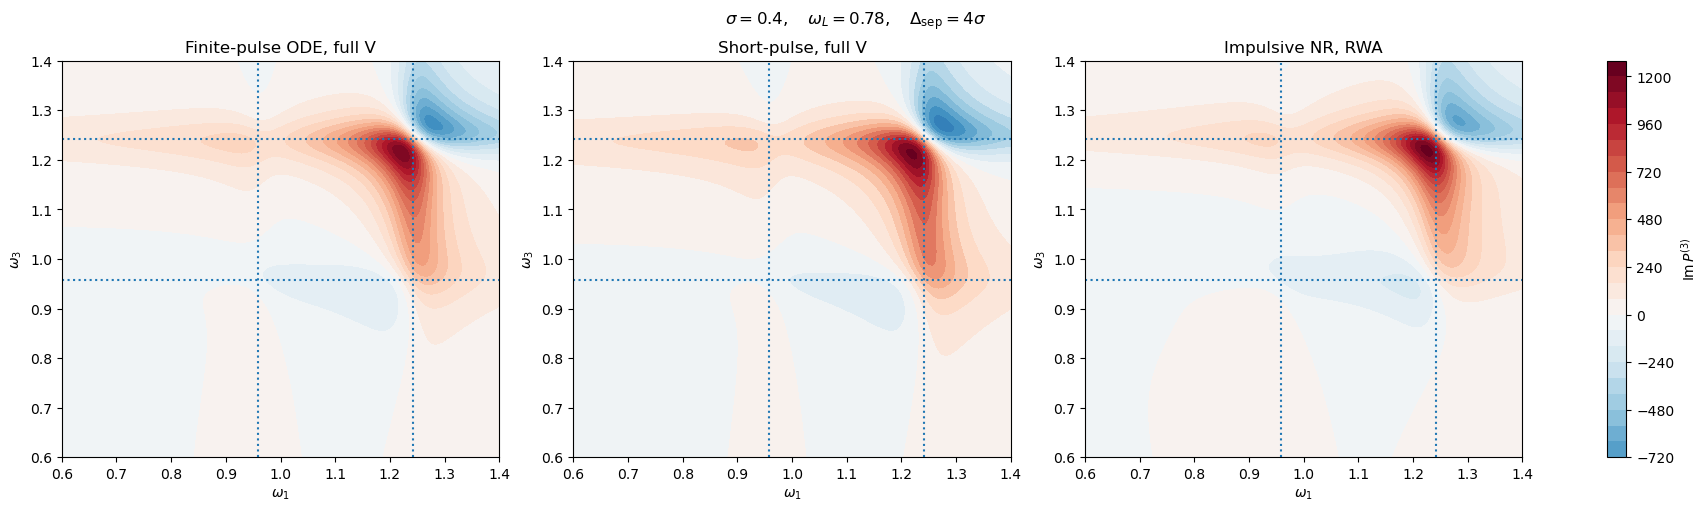

In [137]:
vmax_full_demo = max(
    np.max(
        np.abs(
            np.imag(P_ode_full_demo)
        )
    ),
    np.max(
        np.abs(
            np.imag(P_short_full_demo)
        )
    ),
    np.max(
        np.abs(
            np.imag(M_NR_imp_RWA_demo)
        )
    ),
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 5),
    constrained_layout=True
)

maps_full_demo = [
    np.imag(P_ode_full_demo),
    np.imag(P_short_full_demo),
    np.imag(M_NR_imp_RWA_demo),
]

titles_full_demo = [
    "Finite-pulse ODE, full V",
    "Short-pulse, full V",
    "Impulsive NR, RWA",
]

for ax, Z, title in zip(
    axes,
    maps_full_demo,
    titles_full_demo,
):

    im = ax.contourf(
        omega1_grid,
        omega3_grid,
        Z,
        levels=24,
        vmin=-vmax_full_demo,
        vmax=vmax_full_demo,
        cmap="RdBu_r"
    )

    ax.axvline(
        omega_minus,
        linestyle=":"
    )

    ax.axvline(
        omega_plus,
        linestyle=":"
    )

    ax.axhline(
        omega_minus,
        linestyle=":"
    )

    ax.axhline(
        omega_plus,
        linestyle=":"
    )

    ax.set_xlabel(
        r"$\omega_1$"
    )

    ax.set_ylabel(
        r"$\omega_3$"
    )

    ax.set_title(
        title
    )

fig.colorbar(
    im,
    ax=axes,
    label=r"$\mathrm{Im}\,P^{(3)}$"
)

fig.suptitle(
    r"$\sigma=0.4,\quad "
    r"\omega_L=0.78,\quad "
    r"\Delta_{\rm sep}=4\sigma$"
)

fig.savefig(
    figures_dir
    / "fullV_ode_short_vs_impulsive_RWA_NR.pdf",
    bbox_inches="tight"
)

plt.show()

## 19. Full-V test with the original carrier frequency

We now repeat the full-interaction calculation using the original
carrier frequency

$$
\omega_L=1.1,
$$

while keeping

$$
\sigma=0.4,
\qquad
\Delta_{\mathrm{sep}}=4\sigma=1.6.
$$

The molecular responses calculated above can be reused because they do
not depend on the laser carrier frequency.

In [138]:
sigma_full_11 = 0.4
delay_full_11 = 4.0 * sigma_full_11
omega_L_full_11 = 1.1

tau_grid_full_11 = tau_grid_full_demo.copy()

print("sigma =", sigma_full_11)
print("fixed separation =", delay_full_11)
print("carrier =", omega_L_full_11)

sigma = 0.4
fixed separation = 1.6
carrier = 1.1


In [139]:
E1_full_11 = np.exp(
    -0.5
    * sigma_full_11**2
    * (omega1_grid - omega_L_full_11)**2
)

E2_full_11 = np.exp(
    -0.5
    * sigma_full_11**2
    * (omega1_grid - omega_L_full_11)**2
)

E3_full_11 = np.exp(
    -0.5
    * sigma_full_11**2
    * (omega3_grid - omega_L_full_11)**2
)

E_NR_full_11 = (
    E3_full_11[:, None]
    * (E2_full_11 * E1_full_11)[None, :]
)

P_short_full_11 = (
    E_NR_full_11
    * M_full_demo
)

print("filter min =", np.min(E_NR_full_11))
print("filter max =", np.max(E_NR_full_11))
print("max |P_short| =", np.max(np.abs(P_short_full_11)))

filter min = 0.9417645335842485
filter max = 1.0
max |P_short| = 1686.6947997204798


In [140]:
Q_ode_full_11 = np.zeros(
    (
        len(omega3_grid),
        len(tau_grid_full_11),
    ),
    dtype=complex
)

for i, tau1 in enumerate(tau_grid_full_11):

    Q_ode_full_11[:, i] = (
        NR_ODE_fullV_spectrum_at_tau(
            tau1,
            sigma_full_11,
            delay_full_11,
            omega_L_full_11,
            omega3_grid,
            detector_rows_2d,
        )
    )

    if (
        i % 25 == 0
        or i == len(tau_grid_full_11) - 1
    ):
        print(
            f"{i:3d}/{len(tau_grid_full_11)-1}: "
            f"tau1 = {tau1:.2f}"
        )

  0/300: tau1 = 0.00
 25/300: tau1 = 12.50
 50/300: tau1 = 25.00
 75/300: tau1 = 37.50
100/300: tau1 = 50.00
125/300: tau1 = 62.50
150/300: tau1 = 75.00
175/300: tau1 = 87.50
200/300: tau1 = 100.00
225/300: tau1 = 112.50
250/300: tau1 = 125.00
275/300: tau1 = 137.50
300/300: tau1 = 150.00


In [141]:
phase1_full_11 = np.exp(
    (
        1j * omega1_grid[:, None]
        - eta
    )
    * tau_grid_full_11[None, :]
)

P_ode_full_11 = np.trapezoid(
    Q_ode_full_11[:, None, :]
    * phase1_full_11[None, :, :],
    x=tau_grid_full_11,
    axis=2
)

print(
    "max |P_ode| =",
    np.max(np.abs(P_ode_full_11))
)

max |P_ode| = 1546.908562022747


In [142]:
err_11_ode_short = (
    norm(
        P_ode_full_11
        - P_short_full_11
    )
    /
    norm(P_ode_full_11)
)

err_11_ode_imp = (
    norm(
        P_ode_full_11
        - M_NR_imp_RWA_demo
    )
    /
    norm(P_ode_full_11)
)

diff_11_short_imp = (
    norm(
        P_short_full_11
        - M_NR_imp_RWA_demo
    )
    /
    norm(P_short_full_11)
)

print(
    "Full-V ODE vs full-V short-pulse error (%) =",
    100.0 * err_11_ode_short
)

print(
    "Full-V ODE vs impulsive RWA NR error (%) =",
    100.0 * err_11_ode_imp
)

print(
    "Full-V short-pulse vs impulsive RWA NR difference (%) =",
    100.0 * diff_11_short_imp
)

Full-V ODE vs full-V short-pulse error (%) = 21.75037801702367
Full-V ODE vs impulsive RWA NR error (%) = 20.854272955701934
Full-V short-pulse vs impulsive RWA NR difference (%) = 37.881233595384266


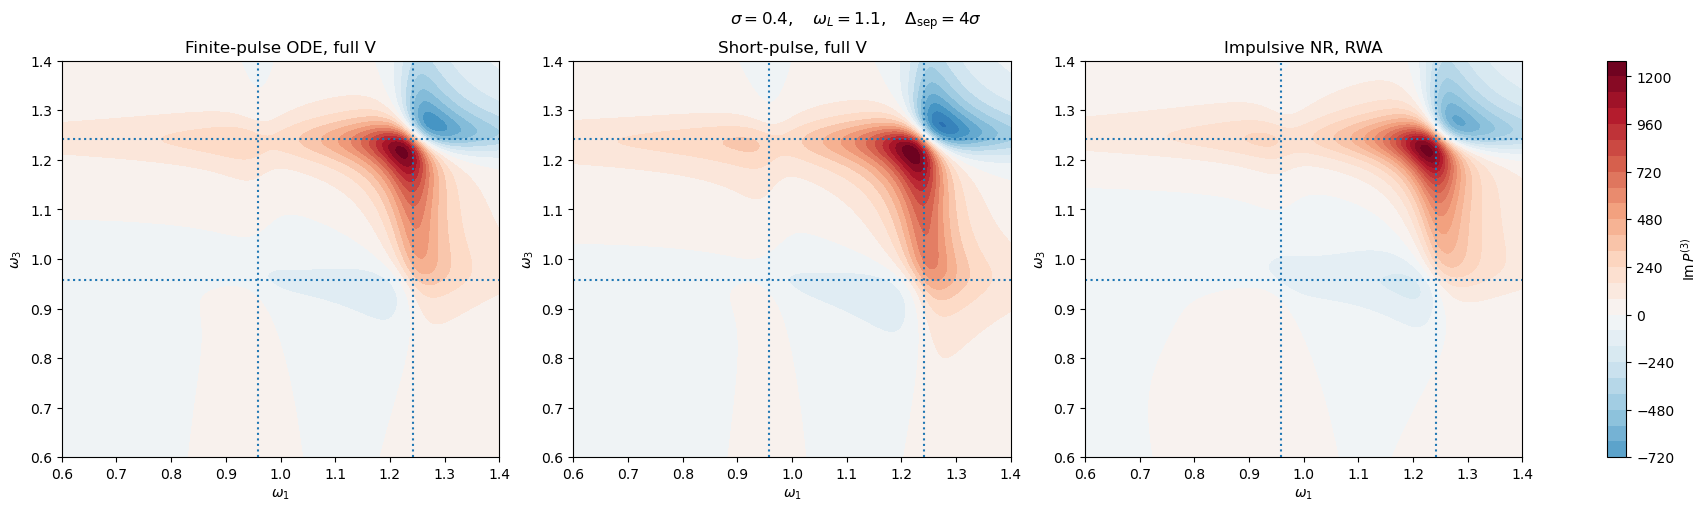

In [143]:
vmax_full_11 = max(
    np.max(np.abs(np.imag(P_ode_full_11))),
    np.max(np.abs(np.imag(P_short_full_11))),
    np.max(np.abs(np.imag(M_NR_imp_RWA_demo))),
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 5),
    constrained_layout=True
)

maps_full_11 = [
    np.imag(P_ode_full_11),
    np.imag(P_short_full_11),
    np.imag(M_NR_imp_RWA_demo),
]

titles_full_11 = [
    "Finite-pulse ODE, full V",
    "Short-pulse, full V",
    "Impulsive NR, RWA",
]

for ax, Z, title in zip(
    axes,
    maps_full_11,
    titles_full_11,
):

    im = ax.contourf(
        omega1_grid,
        omega3_grid,
        Z,
        levels=24,
        vmin=-vmax_full_11,
        vmax=vmax_full_11,
        cmap="RdBu_r"
    )

    ax.axvline(omega_minus, linestyle=":")
    ax.axvline(omega_plus, linestyle=":")
    ax.axhline(omega_minus, linestyle=":")
    ax.axhline(omega_plus, linestyle=":")

    ax.set_xlabel(r"$\omega_1$")
    ax.set_ylabel(r"$\omega_3$")
    ax.set_title(title)

fig.colorbar(
    im,
    ax=axes,
    label=r"$\mathrm{Im}\,P^{(3)}$"
)

fig.suptitle(
    r"$\sigma=0.4,\quad "
    r"\omega_L=1.1,\quad "
    r"\Delta_{\rm sep}=4\sigma$"
)

plt.show()